In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import random

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)


ood_generator = torch.Generator(
    device=device
)

ood_generator.manual_seed(SEED)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)


#DATA

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

svhn_test = torchvision.datasets.SVHN(
    root="./data",
    split="test",
    download=True,
    transform=transform
)


In [ ]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, generator=loader_generator)

test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

svhn_loader = DataLoader(svhn_test, batch_size=64, shuffle=False)

#UTILS

In [ ]:
def sample_uniform_ood(
    batch_size,
    device,
    image_size=(3, 32, 32)
):

    return torch.rand(
        batch_size,
        *image_size,
        device=device,
        generator=ood_generator
    )


def shift_labels(y):

    return y + 1


def get_probs(logits, mode):

    if mode == "onehot":
        return torch.sigmoid(logits)

    return torch.softmax(logits, dim=1)



In [ ]:
def extract_features(model, loader, device):

    model.eval()

    features = []
    labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            feats = model(x)

            features.append(feats.cpu())
            labels.append(y)

    return (
        torch.cat(features),
        torch.cat(labels)
    )

## Train loops

In [ ]:
def train_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    mode="softmax"
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for x, y in loop:

        x = x.to(device)
        y = y.to(device)

        if mode == "onehot":
            targets = F.one_hot(
                y,
                num_classes=model.head.out_features
            ).float()

        else:
            targets = y

        logits = model(x)

        loss = criterion(
            logits,
            targets
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if hasattr(model, "update_statistics"):
            embeddings = model.extract_embedding(x)
            model.update_statistics(
                embeddings,
                y
            )

        probs = get_probs(
            logits,
            mode
        )

        preds = probs.argmax(dim=1)

        correct += (
            preds == y
        ).sum().item()

        total += y.size(0)

        total_loss += loss.item()

        loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    return {
        "loss": total_loss / len(loader),
        "acc": correct / total
    }

In [ ]:
def train_epoch_with_ood(
    model,
    loader,
    criterion,
    optimizer,
    device,
    mode="softmax",
    ood_ratio=1.0
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for x_id, y_id in loop:

        x_id = x_id.to(device)
        y_id = y_id.to(device)

        batch_size = x_id.size(0)

        if mode == "softmax":

            y_id_targets = shift_labels(y_id)

        elif mode == "onehot":

            y_id_targets = F.one_hot(
                y_id,
                num_classes=model.head.out_features
            ).float()

        ood_batch_size = int(
            batch_size * ood_ratio
        )

        x_ood = sample_uniform_ood(
            ood_batch_size,
            device
        )

        if mode == "softmax":

            y_ood_targets = torch.zeros(
                ood_batch_size,
                dtype=torch.long,
                device=device
            )

        elif mode == "onehot":

            y_ood_targets = torch.zeros(
                ood_batch_size,
                model.head.out_features,
                device=device
            )


        x = torch.cat([
            x_id,
            x_ood
        ], dim=0)

        y = torch.cat([
            y_id_targets,
            y_ood_targets
        ], dim=0)

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if hasattr(model, "update_statistics"):
            embeddings = model.extract_embedding(x)
            model.update_statistics(
                embeddings,
                y
            )

        probs_id = get_probs(
            logits[:batch_size],
            mode
        )

        preds_id = probs_id.argmax(dim=1)

        correct += (
            preds_id == y_id
        ).sum().item()

        total += batch_size

        total_loss += loss.item()

        loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    return {
        "loss": total_loss / len(loader),
        "acc": correct / total
    }


In [ ]:
def fit(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    mode="softmax",
    use_ood=False,
    ood_ratio=1.0
):

    history = []

    for epoch in range(epochs):

        if use_ood:

            metrics = train_epoch_with_ood(
                model=model,
                loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
                mode=mode,
                ood_ratio=ood_ratio
            )

        else:

            metrics = train_epoch(
                model=model,
                loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
                mode=mode
            )

        history.append(metrics)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"loss={metrics['loss']:.4f} | "
            f"acc={metrics['acc']:.4f}"
        )

    return history

##Evaluate

In [ ]:
def evaluate_model(
    model,
    loader,
    device,
    mode="softmax",
    ood_class=False
):

    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            logits = model(x)

            probs = get_probs(logits, mode)
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())

            if ood_class:
                y = shift_labels(y)
            all_labels.append(y)

    probs = torch.cat(all_probs)
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    return {
        "probs": probs,
        "preds": preds,
        "labels": labels
    }

In [ ]:
def progressive_training_evaluation(
    model,
    criterion,
    optimizer,
    train_loader,
    id_loader,
    ood_loader,
    device,
    steps=10,
    train_steps=10,
    ood_mode=True,
    model_mode='softmax',
    ood_ratio=1.0,
    score_mode="msp"
):

    fr_list = []
    orr_list = []

    for step in range(steps):

        fit(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epochs=train_steps,
            mode=model_mode,
            use_ood=ood_mode,
            ood_ratio=ood_ratio)

        id_scores = evaluate_model(
            model=model,
            loader=id_loader,
            device=device,
            mode=model_mode)
        ood_scores = evaluate_model(
            model=model,
            loader=ood_loader,
            device=device,
            mode=model_mode)

        computed = compute_reject_curves(id_scores["probs"], ood_scores["probs"], score_mode=score_mode)

        thresholds, fr, orr = computed["thresholds"], computed["false_reject"], computed["ood_reject"]

        fr_list.append(fr.mean())
        orr_list.append(orr.mean())
        print(f"step: {step+1}/{steps}: \n\tFR = {fr.mean()}\n\tORR = {orr.mean()}\n" + "="*20)

    return fr_list, orr_list

##Metrics

In [ ]:
def classification_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    return {
        "accuracy": acc,
        "report": report,
        "confusion_matrix": cm
    }

In [ ]:
def compute_entropy(probs):

    return -torch.sum(
        probs * torch.log(probs + 1e-8),
        dim=1
    )


def compute_msp(probs):

    return probs.max(dim=1).values

In [ ]:
def prepare_ood_labels(id_scores, ood_scores):

    labels = np.concatenate([
        np.zeros(len(id_scores)),
        np.ones(len(ood_scores))
    ])

    scores = np.concatenate([
        id_scores,
        ood_scores
    ])

    return labels, scores

In [ ]:
def compute_ood_metrics(
    id_probs,
    ood_probs
):

    entropy_id = compute_entropy(id_probs)
    entropy_ood = compute_entropy(ood_probs)

    msp_id = compute_msp(id_probs)
    msp_ood = compute_msp(ood_probs)

    labels_entropy, scores_entropy = prepare_ood_labels(
        entropy_id.numpy(),
        entropy_ood.numpy()
    )

    labels_msp, scores_msp = prepare_ood_labels(
        (-msp_id).numpy(),
        (-msp_ood).numpy()
    )

    auroc_entropy = roc_auc_score(
        labels_entropy,
        scores_entropy
    )

    auroc_msp = roc_auc_score(
        labels_msp,
        scores_msp
    )

    fpr_entropy, tpr_entropy, _ = roc_curve(
        labels_entropy,
        scores_entropy
    )

    fpr_msp, tpr_msp, _ = roc_curve(
        labels_msp,
        scores_msp
    )

    return {
        "entropy": {
            "id": entropy_id,
            "ood": entropy_ood,
            "auroc": auroc_entropy,
            "fpr": fpr_entropy,
            "tpr": tpr_entropy
        },

        "msp": {
            "id": msp_id,
            "ood": msp_ood,
            "auroc": auroc_msp,
            "fpr": fpr_msp,
            "tpr": tpr_msp
        }
    }


In [ ]:
def compute_reject_curves(
    id_probs,
    ood_probs,
    model_name="Model",
    n_thresholds=50,
    score_mode="msp"
    ):
    if score_mode == "msp":
        id_scores = compute_msp(id_probs).cpu().numpy()
        ood_scores = compute_msp(ood_probs).cpu().numpy()
    elif score_mode == "entropy":
        id_scores = compute_entropy(id_probs).cpu().numpy()
        ood_scores = compute_entropy(ood_probs).cpu().numpy()


    thresholds = np.linspace(0.0, 1.0, n_thresholds)

    false_reject_rates = []
    ood_reject_rates = []

    loop = tqdm(thresholds, desc=f"{model_name} reject curves")

    for t in loop:
        if score_mode == "msp":
            fr = np.mean(id_scores < t)
            orr = np.mean(ood_scores < t)
        elif score_mode == "entropy":
            fr = np.mean(id_scores > t)
            orr = np.mean(ood_scores > t)

        false_reject_rates.append(fr)
        ood_reject_rates.append(orr)


    return {
        "thresholds": thresholds,
        "false_reject": np.array(false_reject_rates),
        "ood_reject": np.array(ood_reject_rates)
    }

##Plotting

In [ ]:
def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(6, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(title)

    plt.show()

In [ ]:
def plot_ood_distributions(
    id_scores,
    ood_scores,
    title,
    xlabel
):

    plt.figure(figsize=(8, 5))

    plt.hist(
        id_scores,
        bins=50,
        alpha=0.6,
        label="ID"
    )

    plt.hist(
        ood_scores,
        bins=50,
        alpha=0.6,
        label="OOD"
    )

    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.title(title)

    plt.legend()

    plt.show()

In [ ]:
def plot_ood_roc(
    fpr,
    tpr,
    auroc,
    title
):

    plt.figure(figsize=(6, 6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUROC = {auroc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.show()

In [ ]:
def evaluate_ood(
    id_probs,
    ood_probs,
    model_name="Model"
):

    metrics = compute_ood_metrics(
        id_probs,
        ood_probs
    )

    plot_ood_distributions(
        metrics["entropy"]["id"].numpy(),
        metrics["entropy"]["ood"].numpy(),
        title=f"{model_name}: Entropy Distribution",
        xlabel="Entropy"
    )

    plot_ood_distributions(
        metrics["msp"]["id"].numpy(),
        metrics["msp"]["ood"].numpy(),
        title=f"{model_name}: MSP Distribution",
        xlabel="MSP"
    )

    plot_ood_roc(
        metrics["entropy"]["fpr"],
        metrics["entropy"]["tpr"],
        metrics["entropy"]["auroc"],
        title=f"{model_name}: ROC (Entropy)"
    )

    plot_ood_roc(
        metrics["msp"]["fpr"],
        metrics["msp"]["tpr"],
        metrics["msp"]["auroc"],
        title=f"{model_name}: ROC (MSP)"
    )

    print(f"{model_name} OOD Metrics")
    print("-" * 40)

    print(
        f"Entropy AUROC: "
        f"{metrics['entropy']['auroc']:.4f}"
    )

    print(
        f"MSP AUROC: "
        f"{metrics['msp']['auroc']:.4f}"
    )

    return metrics

In [ ]:
def plot_reject_curve(
        ax,
        id_probs,
        ood_probs,
        model_name="Model",
        score_mode="msp",
        n_thresholds=50
    ):
    computed = compute_reject_curves(
        id_probs,
        ood_probs,
        model_name=model_name,
        score_mode=score_mode,
        n_thresholds=n_thresholds)

    thresholds, false_reject_rates, ood_reject_rates = computed["thresholds"], computed["false_reject"], computed["ood_reject"]

    ax.plot(
        thresholds,
        false_reject_rates,
        label="False Reject Rate (ID)"
    )

    ax.plot(
        thresholds,
        ood_reject_rates,
        label="OOD Reject Rate"
    )
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Reject Rate")

    ax.set_title(f"{model_name}: Reject Rates vs Threshold on {score_mode}")

    ax.legend()
    ax.grid(True)

def plot_reject_curves(
        id_probs,
        ood_probs,
        model_name="Model",
        n_thresholds=50
    ):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_reject_curve(
        ax=axes[0],
        id_probs=id_probs,
        ood_probs=ood_probs,
        model_name=model_name,
        score_mode="msp",
        n_thresholds=50)
    plot_reject_curve(
        ax=axes[1],
        id_probs=id_probs,
        ood_probs=ood_probs,
        model_name=model_name,
        score_mode="entropy",
        n_thresholds=50)
    plt.show()



In [ ]:
def plot_reject_rate_by_epochs(epochs, fr_list, orr_list, model):
    plt.figure(figsize=(10, 6))

    plt.plot(
        range(*epochs),
        fr_list,
        label="False Reject Rate (ID)"
    )
    plt.plot(
        range(*epochs),
        orr_list,
        label="OOD Reject Rate"
    )



    plt.xlabel("Epochs")
    plt.ylabel("Reject Rate")

    plt.title(f"{model}: Reject Rates with progress")

    plt.legend()
    plt.grid(True)

    plt.show()

#MODEL WITHOUT OOD CLASS

## BASELINE

In [ ]:
class FeatureCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

##HEADS

###Baseline

In [ ]:
class CNN_SOFTMAX(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = FeatureCNN()
        self.head = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

In [ ]:
basemodel = CNN_SOFTMAX().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    basemodel.parameters(),
    lr=1e-3
)

fit(
    model=basemodel,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="softmax",
    use_ood=False
)

results_base = evaluate_model(
    basemodel,
    test_loader,
    device
)

metrics_base = classification_metrics(
    results_base["labels"].numpy(),
    results_base["preds"].numpy()
)

print(metrics_base["report"])

100%|██████████| 782/782 [00:12<00:00, 63.29it/s, acc=0.47, loss=1.53]


Epoch 1/10 | loss=1.4734 | acc=0.4698


100%|██████████| 782/782 [00:12<00:00, 64.52it/s, acc=0.617, loss=0.905]


Epoch 2/10 | loss=1.0877 | acc=0.6175


100%|██████████| 782/782 [00:12<00:00, 64.21it/s, acc=0.682, loss=0.532]


...

Epoch 8/10 | loss=0.5622 | acc=0.8057


100%|██████████| 782/782 [00:12<00:00, 64.49it/s, acc=0.822, loss=0.991]


Epoch 9/10 | loss=0.5144 | acc=0.8220


100%|██████████| 782/782 [00:12<00:00, 63.79it/s, acc=0.835, loss=0.284]


Epoch 10/10 | loss=0.4740 | acc=0.8353
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      1000
           1       0.81      0.90      0.86      1000
           2       0.68      0.61      0.64      1000
           3       0.62      0.50      0.55      1000
           4       0.70      0.69      0.70      1000
           5       0.63      0.70      0.66      1000
           6       0.73      0.86      0.79      1000
           7       0.77      0.81      0.79      1000
           8       0.87      0.83      0.85      1000
           9       0.86      0.76      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



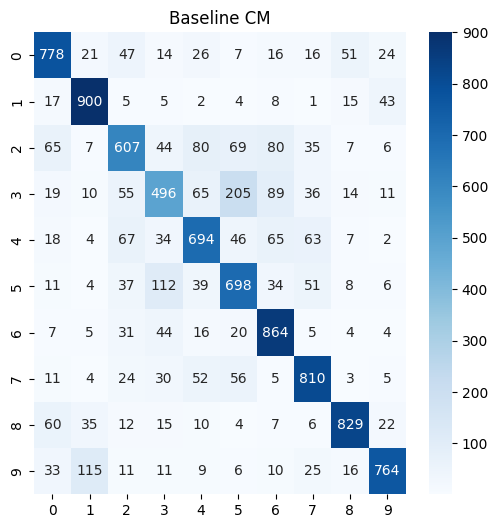

In [ ]:
plot_confusion_matrix(metrics_base["confusion_matrix"], title="Baseline CM")

###Gaussian NB

In [ ]:
cnn = basemodel.backbone

for param in cnn.parameters():
    param.requires_grad = False

cnn.eval()

FeatureCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

In [ ]:
X_train_on_base, y_train_on_base = extract_features(cnn, train_loader, device)
X_test_on_base, y_test_on_base = extract_features(cnn, test_loader, device)
X_svhn_on_base, y_svhn_on_base = extract_features(cnn, svhn_loader, device)

In [ ]:
nb = GaussianNB()
nb.fit(X_train_on_base.numpy(), y_train_on_base.numpy())

GaussianNB()

In [ ]:
metrics_nb = classification_metrics(
    y_test_on_base.numpy(),
    nb.predict(X_test_on_base)
)

print(metrics_nb["report"])

              precision    recall  f1-score   support

           0       0.65      0.59      0.62      1000
           1       0.71      0.74      0.73      1000
           2       0.53      0.31      0.39      1000
           3       0.43      0.36      0.39      1000
           4       0.49      0.58      0.53      1000
           5       0.52      0.55      0.53      1000
           6       0.60      0.76      0.67      1000
           7       0.70      0.61      0.65      1000
           8       0.62      0.76      0.68      1000
           9       0.69      0.68      0.69      1000

    accuracy                           0.60     10000
   macro avg       0.59      0.60      0.59     10000
weighted avg       0.59      0.60      0.59     10000



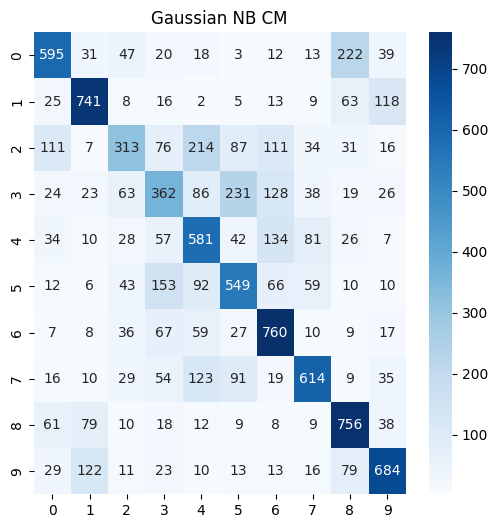

In [ ]:
plot_confusion_matrix(metrics_nb["confusion_matrix"], title="Gaussian NB CM")

###Bayesian

In [ ]:
class BayesianCNN(nn.Module):

    def __init__(
        self,
        num_classes=10,
        embedding_dim=128
    ):
        super().__init__()

        self.num_classes = num_classes

        self.backbone = FeatureCNN()

        self.embedding = nn.Linear(
            128 * 4 * 4,
            embedding_dim
        )

        self.head = nn.Identity()

        self.register_buffer(
            "class_count",
            torch.zeros(num_classes)
        )

        self.register_buffer(
            "class_mean",
            torch.zeros(
                num_classes,
                embedding_dim
            )
        )

        self.register_buffer(
            "class_var",
            torch.ones(
                num_classes,
                embedding_dim
            )
        )

        self.eps = 1e-6

    def extract_embedding(self, x):

        feats = self.backbone(x)

        return self.embedding(feats)

    def forward(self, x):

        z = self.extract_embedding(x)

        means = self.class_mean.unsqueeze(0)
        vars_ = self.class_var.unsqueeze(0)

        diff = z.unsqueeze(1) - means

        log_likelihood = -0.5 * (
            (diff ** 2 / vars_).sum(dim=2)
            +
            torch.log(vars_).sum(dim=2)
        )

        prior = (
            self.class_count + self.eps
        )

        prior = prior / prior.sum()

        log_prior = torch.log(prior)

        logits = (
            log_likelihood
            +
            log_prior.unsqueeze(0)
        )

        return logits

    @torch.no_grad()
    def update_statistics(
        self,
        embeddings,
        labels
    ):

        for c in range(self.num_classes):

            mask = labels == c

            if mask.sum() == 0:
                continue

            z = embeddings[mask]

            batch_count = z.size(0)

            batch_mean = z.mean(dim=0)

            batch_var = z.var(
                dim=0,
                unbiased=False
            )

            old_count = self.class_count[c]

            new_count = (
                old_count
                +
                batch_count
            )

            if old_count.item() == 0:

                self.class_mean[c] = batch_mean

                self.class_var[c] = (
                    batch_var
                    +
                    self.eps
                )

            else:

                old_mean = self.class_mean[c]

                old_var = self.class_var[c]

                delta = (
                    batch_mean
                    -
                    old_mean
                )

                new_mean = (
                    old_count * old_mean
                    +
                    batch_count * batch_mean
                ) / new_count

                new_var = (
                    old_count * (
                        old_var
                        +
                        (old_mean - new_mean) ** 2
                    )
                    +
                    batch_count * (
                        batch_var
                        +
                        (batch_mean - new_mean) ** 2
                    )
                ) / new_count

                self.class_mean[c] = new_mean

                self.class_var[c] = (
                    new_var
                    +
                    self.eps
                )

            self.class_count[c] = new_count


In [ ]:
bayes_model = BayesianCNN(
    num_classes=10,
    embedding_dim=128
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    list(bayes_model.backbone.parameters())
    +
    list(bayes_model.embedding.parameters()),
    lr=1e-3
)


fit(
    model=bayes_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="softmax",
    use_ood=False
)

results_bayes = evaluate_model(
    bayes_model,
    test_loader,
    device
)

metrics_bayes = classification_metrics(
    results_bayes["labels"].numpy(),
    results_bayes["preds"].numpy()
)

print(metrics_bayes["report"])

100%|██████████| 782/782 [00:18<00:00, 42.08it/s, acc=0.351, loss=1.35]


Epoch 1/10 | loss=2.3312 | acc=0.3511


100%|██████████| 782/782 [00:18<00:00, 42.68it/s, acc=0.525, loss=0.984]


Epoch 2/10 | loss=1.3047 | acc=0.5253


100%|██████████| 782/782 [00:18<00:00, 43.05it/s, acc=0.589, loss=1.67]


...

Epoch 8/10 | loss=0.7666 | acc=0.7306


100%|██████████| 782/782 [00:18<00:00, 43.26it/s, acc=0.741, loss=0.593]


Epoch 9/10 | loss=0.7369 | acc=0.7413


100%|██████████| 782/782 [00:18<00:00, 41.91it/s, acc=0.757, loss=0.975]


Epoch 10/10 | loss=0.6913 | acc=0.7574
              precision    recall  f1-score   support

           0       0.80      0.65      0.72      1000
           1       0.87      0.78      0.82      1000
           2       0.63      0.51      0.57      1000
           3       0.51      0.49      0.50      1000
           4       0.60      0.67      0.64      1000
           5       0.61      0.62      0.62      1000
           6       0.71      0.83      0.77      1000
           7       0.79      0.71      0.75      1000
           8       0.77      0.83      0.80      1000
           9       0.67      0.83      0.75      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



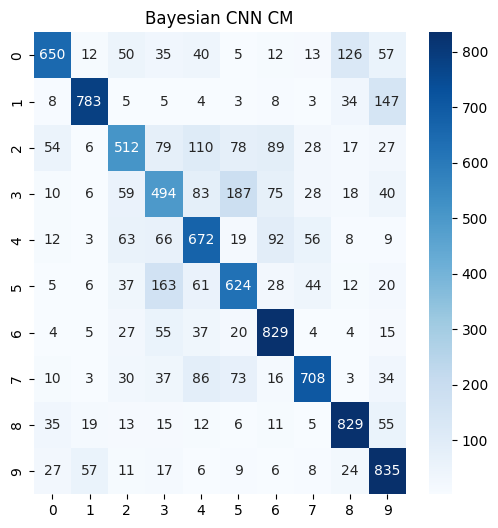

In [ ]:
plot_confusion_matrix(
    metrics_bayes["confusion_matrix"],
    title="Bayesian CNN CM"
)

##EVALUATION

###Baseline

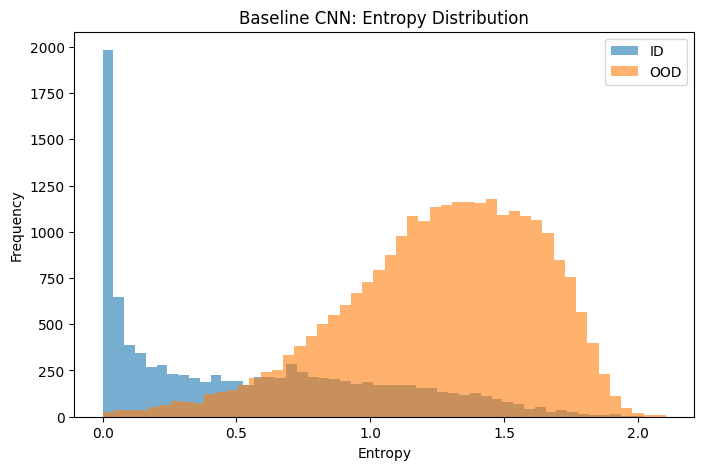

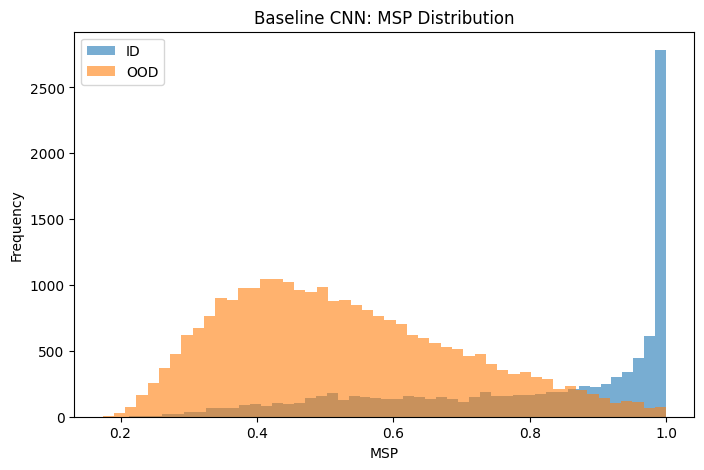

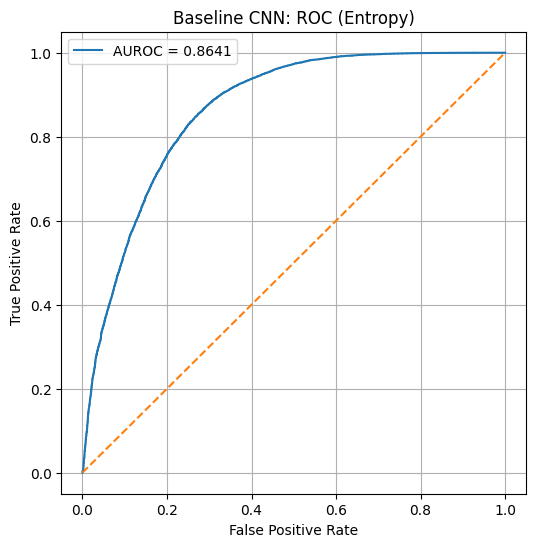

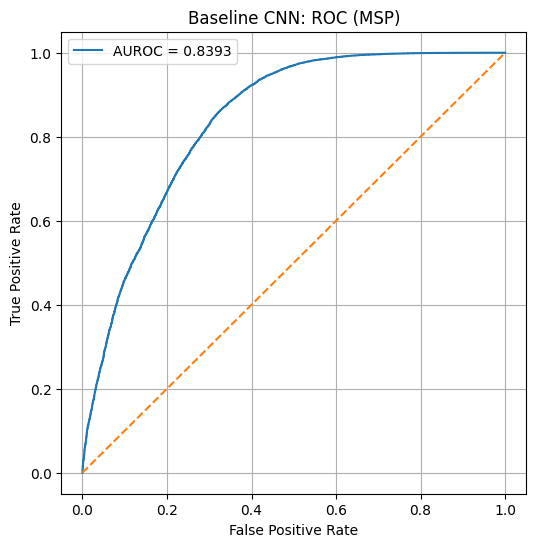

Baseline CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8641
MSP AUROC: 0.8393


In [ ]:
basemodel_id_results = evaluate_model(
    model=basemodel,
    loader=test_loader,
    device=device
)

basemodel_ood_results = evaluate_model(
    model=basemodel,
    loader=svhn_loader,
    device=device
)
baseline_metrics = evaluate_ood(
    id_probs=basemodel_id_results["probs"],
    ood_probs=basemodel_ood_results["probs"],
    model_name="Baseline CNN"
)

Baseline CNN reject curves: 100%|██████████| 50/50 [00:00<00:00, 8132.28it/s]


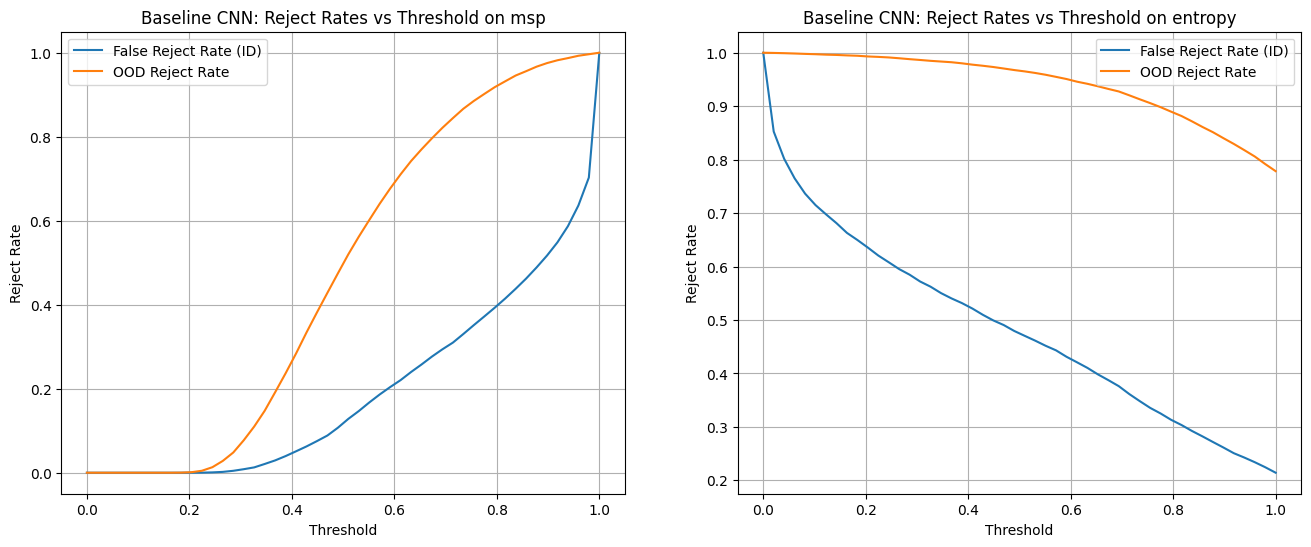

In [ ]:
plot_reject_curves(
    id_probs=basemodel_id_results["probs"],
    ood_probs=basemodel_ood_results["probs"],
    model_name="Baseline CNN"
)

###Gaussian NB

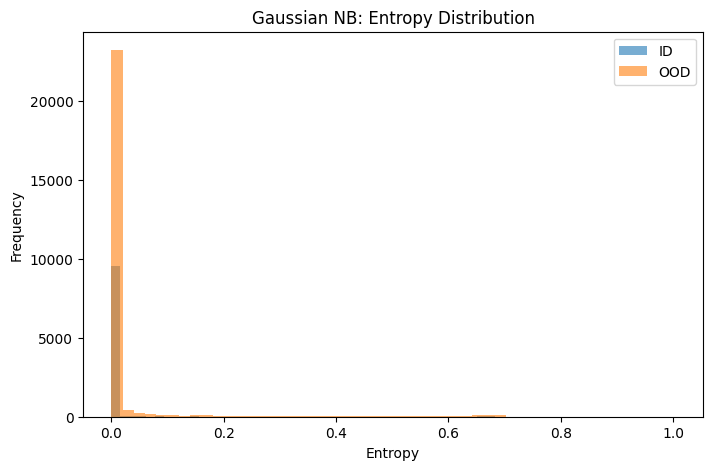

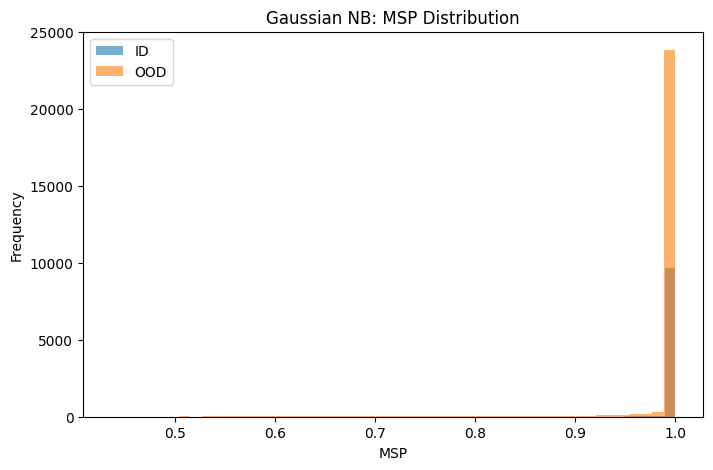

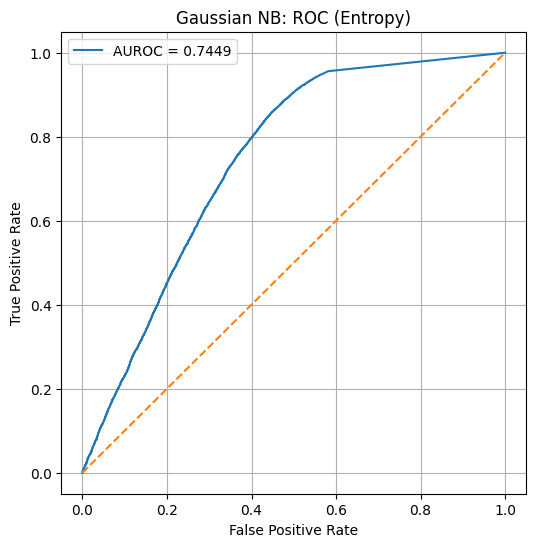

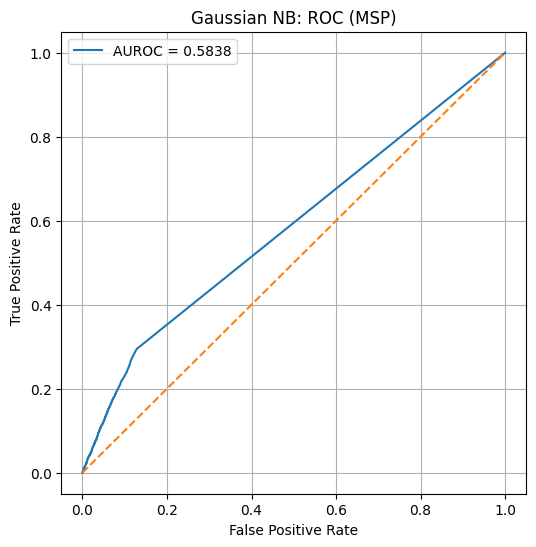

Gaussian NB OOD Metrics
----------------------------------------
Entropy AUROC: 0.7449
MSP AUROC: 0.5838


In [ ]:
nb_probs_id = torch.tensor(
    nb.predict_proba(X_test_on_base.numpy())
).float()

nb_probs_ood = torch.tensor(
    nb.predict_proba(X_svhn_on_base.numpy())
).float()

nb_metrics = evaluate_ood(
    id_probs=nb_probs_id,
    ood_probs=nb_probs_ood,
    model_name="Gaussian NB"
)

Gaussian NB reject curves: 100%|██████████| 50/50 [00:00<00:00, 11115.45it/s]


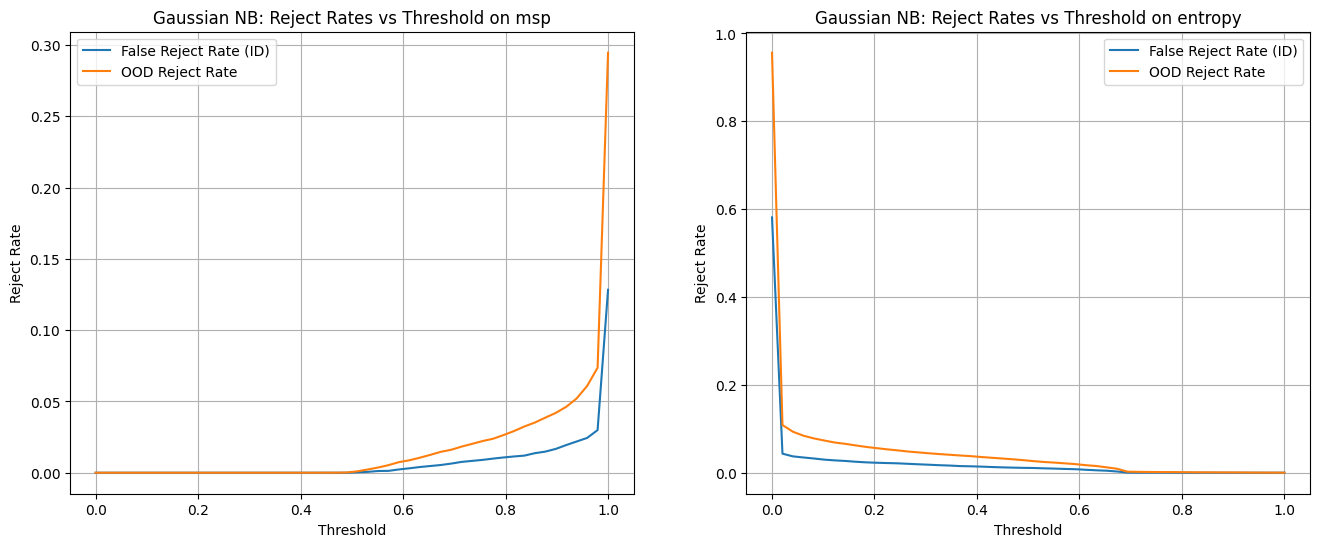

In [ ]:
plot_reject_curves(
    id_probs=nb_probs_id,
    ood_probs=nb_probs_ood,
    model_name="Gaussian NB"
)

###Bayesian

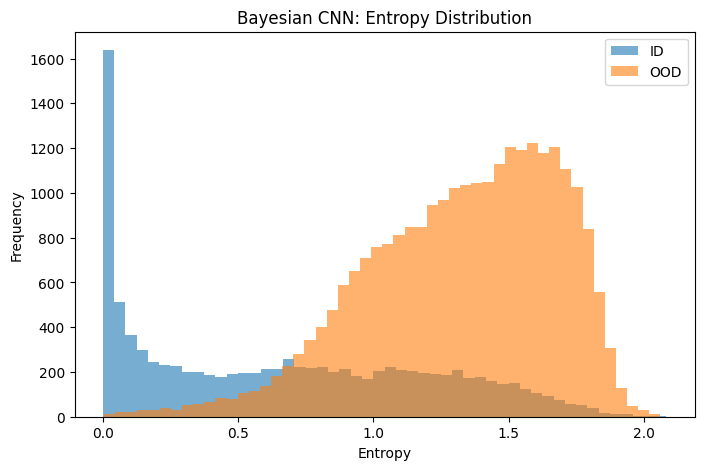

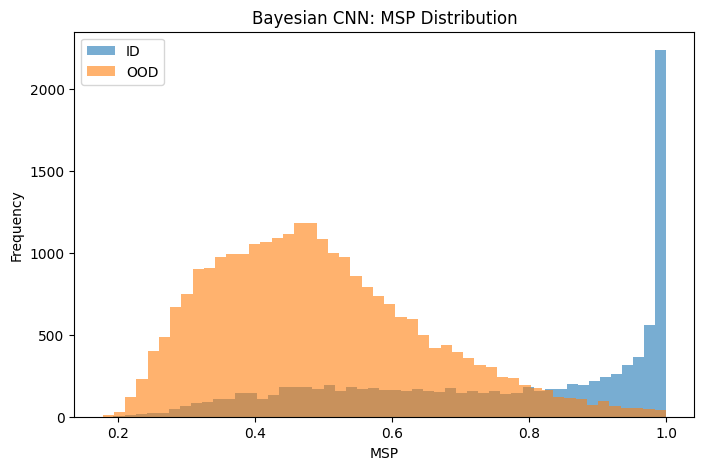

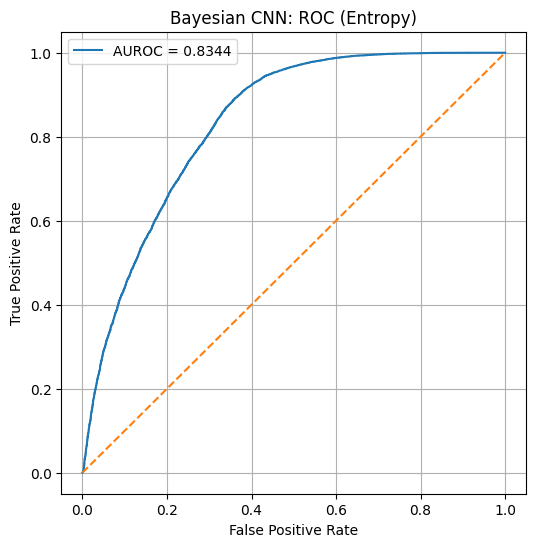

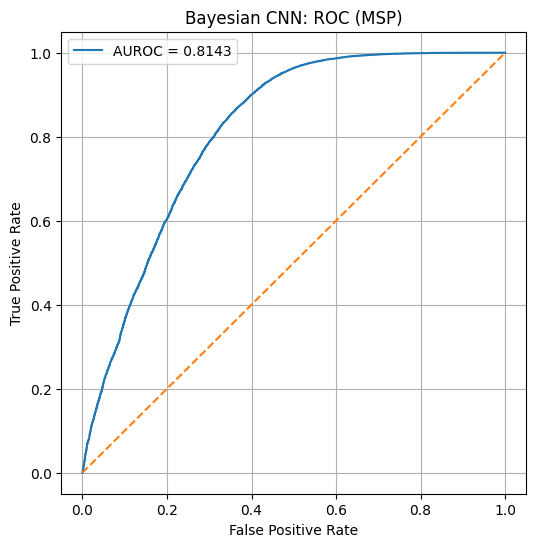

Bayesian CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8344
MSP AUROC: 0.8143


In [ ]:
bayes_id_results = evaluate_model(
    model=bayes_model,
    loader=test_loader,
    device=device
)

bayes_ood_results = evaluate_model(
    model=bayes_model,
    loader=svhn_loader,
    device=device
)
bayes_metrics = evaluate_ood(
    id_probs=bayes_id_results["probs"],
    ood_probs=bayes_ood_results["probs"],
    model_name="Bayesian CNN"
)

Bayesian CNN reject curves: 100%|██████████| 50/50 [00:00<00:00, 7066.11it/s]


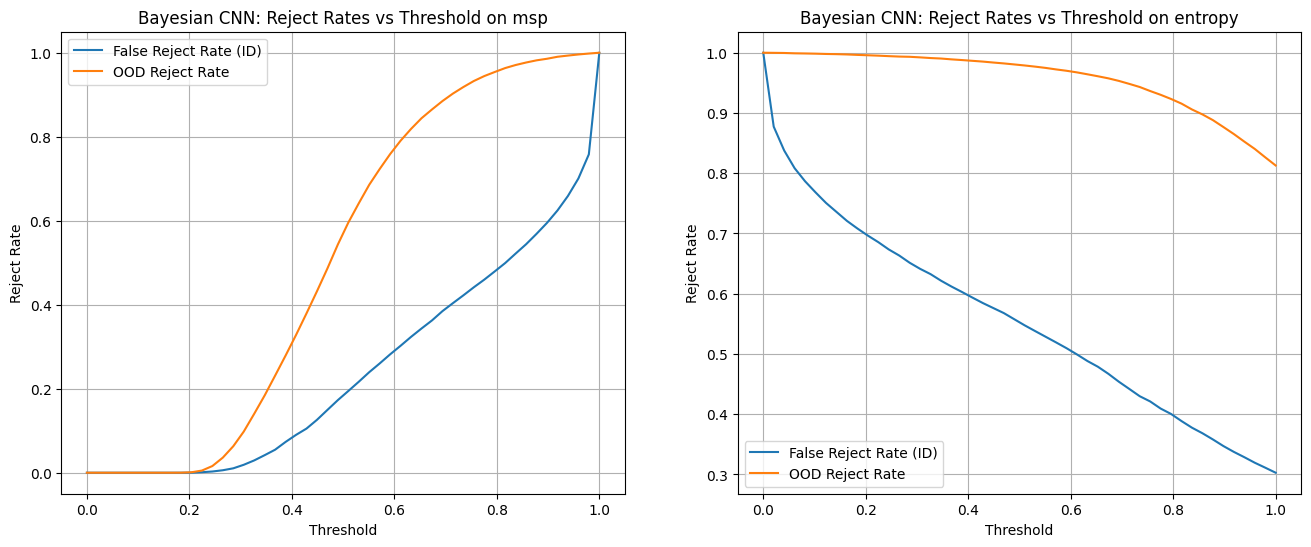

In [ ]:
plot_reject_curves(
    id_probs=bayes_id_results["probs"],
    ood_probs=bayes_ood_results["probs"],
    model_name="Bayesian CNN"
)

# MODEL WITH OOD CLASS

In [ ]:
ood_ratio = 1.0

##MODELS

###Baseline with OOD

In [ ]:
basemodel_OOD = CNN_SOFTMAX(num_classes=11).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    basemodel_OOD.parameters(),
    lr=1e-3
    )

fit(
    model=basemodel_OOD,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="softmax",
    use_ood=True,
    ood_ratio = ood_ratio
)

results_base_ood = evaluate_model(
    basemodel_OOD,
    test_loader,
    device,
    ood_class = True
)

metrics_base_ood = classification_metrics(
    results_base_ood["labels"].numpy(),
    results_base_ood["preds"].numpy()
)

print(metrics_base_ood["report"])

100%|██████████| 782/782 [00:13<00:00, 55.91it/s, acc=0.0561, loss=0.58]


Epoch 1/10 | loss=0.8211 | acc=0.0561


100%|██████████| 782/782 [00:14<00:00, 55.71it/s, acc=0.035, loss=0.53]


Epoch 2/10 | loss=0.5850 | acc=0.0350


100%|██████████| 782/782 [00:14<00:00, 55.81it/s, acc=0.0295, loss=0.331]


...

Epoch 8/10 | loss=0.3015 | acc=0.0197


100%|██████████| 782/782 [00:14<00:00, 54.71it/s, acc=0.0193, loss=0.577]


Epoch 9/10 | loss=0.2792 | acc=0.0193


100%|██████████| 782/782 [00:14<00:00, 55.26it/s, acc=0.0175, loss=0.168]


Epoch 10/10 | loss=0.2580 | acc=0.0175
              precision    recall  f1-score   support

           1       0.75      0.76      0.76      1000
           2       0.92      0.75      0.83      1000
           3       0.56      0.71      0.63      1000
           4       0.64      0.50      0.56      1000
           5       0.68      0.72      0.70      1000
           6       0.72      0.58      0.64      1000
           7       0.75      0.84      0.79      1000
           8       0.81      0.78      0.79      1000
           9       0.78      0.89      0.83      1000
          10       0.82      0.84      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



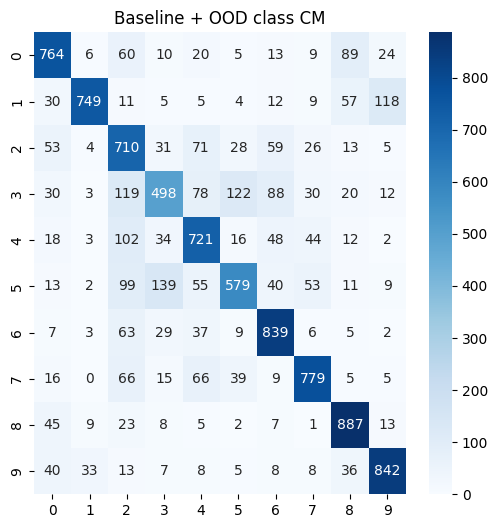

In [ ]:
plot_confusion_matrix(metrics_base_ood["confusion_matrix"], title="Baseline + OOD class CM")

###Gaussian NB with OOD

In [ ]:
cnn_OOD = basemodel_OOD.backbone

for param in cnn_OOD.parameters():
    param.requires_grad = False

cnn_OOD.eval()

FeatureCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

In [ ]:
X_test_on_OOD, y_test_on_OOD = extract_features(cnn_OOD, test_loader, device)
X_svhn_on_OOD, y_svhn_on_OOD = extract_features(cnn_OOD, svhn_loader, device)

In [ ]:
X_train_on_OOD, y_train_on_OOD = extract_features(cnn_OOD, train_loader, device)

ood_batch = int(X_train_on_OOD.size(0) * ood_ratio)

x_ood = sample_uniform_ood(ood_batch, device)

X_ood = cnn_OOD(x_ood).cpu()
y_ood = torch.zeros(ood_batch, dtype=torch.long)

X_train_on_OOD = torch.cat([X_train_on_OOD, X_ood])
y_train_on_OOD = torch.cat([shift_labels(y_train_on_OOD), y_ood])

In [ ]:
nb_OOD = GaussianNB()
nb_OOD.fit(X_train_on_OOD.numpy(), y_train_on_OOD.numpy())

GaussianNB()

In [ ]:
metrics_nb_ood = classification_metrics(
    shift_labels(y_test_on_OOD).numpy(),
    nb_OOD.predict(X_test_on_OOD)
)

print(metrics_nb_ood["report"])

              precision    recall  f1-score   support

           1       0.63      0.52      0.57      1000
           2       0.68      0.70      0.69      1000
           3       0.53      0.17      0.26      1000
           4       0.45      0.29      0.35      1000
           5       0.40      0.62      0.49      1000
           6       0.51      0.54      0.52      1000
           7       0.58      0.75      0.65      1000
           8       0.64      0.61      0.63      1000
           9       0.57      0.77      0.65      1000
          10       0.69      0.67      0.68      1000

    accuracy                           0.56     10000
   macro avg       0.57      0.56      0.55     10000
weighted avg       0.57      0.56      0.55     10000



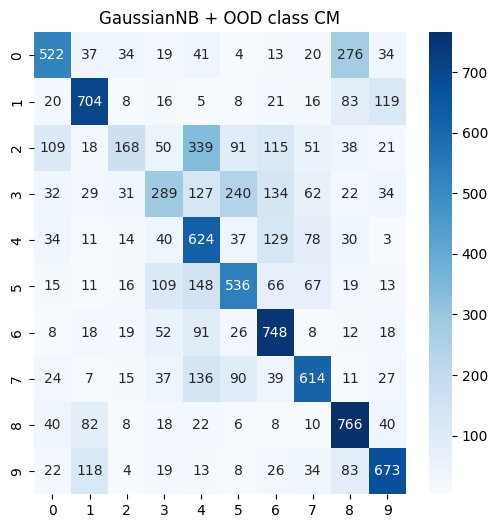

In [ ]:
plot_confusion_matrix(metrics_nb_ood["confusion_matrix"], title="GaussianNB + OOD class CM")

###Bayesian with OOD

In [ ]:
bayes_OOD = BayesianCNN(
    num_classes=11
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optimizer = torch.optim.Adam(
    list(bayes_OOD.backbone.parameters())
    +
    list(bayes_OOD.embedding.parameters()),
    lr=1e-3
)

fit(
    model=bayes_OOD,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="softmax",
    use_ood=True,
    ood_ratio=1.0
)

results_bayes_ood = evaluate_model(
    bayes_OOD,
    test_loader,
    device,
    ood_class = True
)

metrics_bayes_ood = classification_metrics(
    results_bayes_ood["labels"].numpy(),
    results_bayes_ood["preds"].numpy()
)

print(metrics_bayes_ood["report"])

100%|██████████| 782/782 [00:20<00:00, 38.92it/s, acc=0.0767, loss=1.22]


Epoch 1/10 | loss=2.4976 | acc=0.0767


100%|██████████| 782/782 [00:20<00:00, 38.37it/s, acc=0.0527, loss=1.29]


Epoch 2/10 | loss=0.7744 | acc=0.0527


100%|██████████| 782/782 [00:19<00:00, 39.12it/s, acc=0.0448, loss=0.684]


...

Epoch 8/10 | loss=0.4938 | acc=0.0310


100%|██████████| 782/782 [00:19<00:00, 39.27it/s, acc=0.0291, loss=0.538]


Epoch 9/10 | loss=0.4645 | acc=0.0291


100%|██████████| 782/782 [00:20<00:00, 38.27it/s, acc=0.0284, loss=0.357]


Epoch 10/10 | loss=0.4436 | acc=0.0284
              precision    recall  f1-score   support

           1       0.74      0.66      0.69      1000
           2       0.85      0.77      0.81      1000
           3       0.63      0.49      0.55      1000
           4       0.51      0.47      0.49      1000
           5       0.60      0.66      0.63      1000
           6       0.56      0.63      0.59      1000
           7       0.84      0.65      0.73      1000
           8       0.69      0.76      0.72      1000
           9       0.69      0.88      0.77      1000
          10       0.71      0.82      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



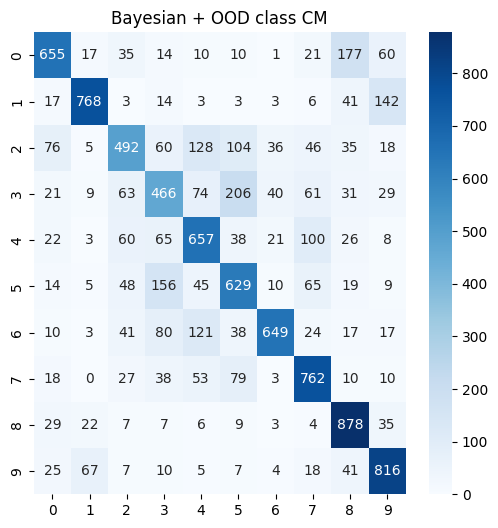

In [ ]:
plot_confusion_matrix(metrics_bayes_ood["confusion_matrix"], title="Bayesian + OOD class CM")

##EVALUATION

###Baseline with OOD

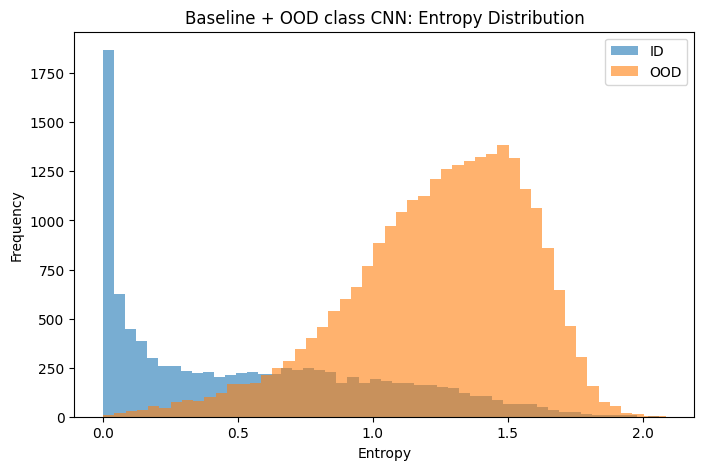

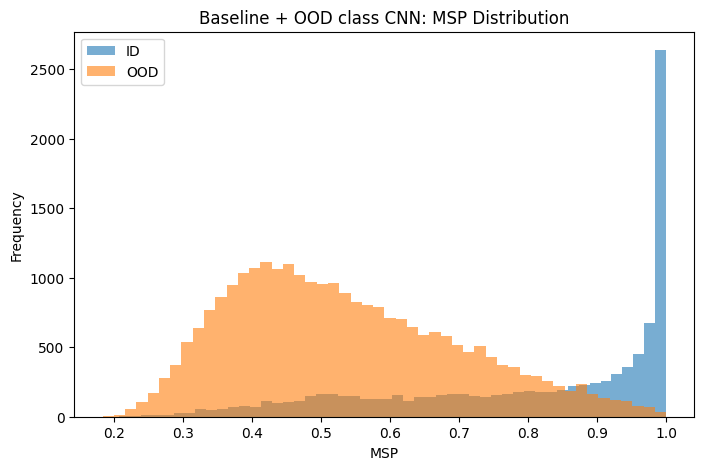

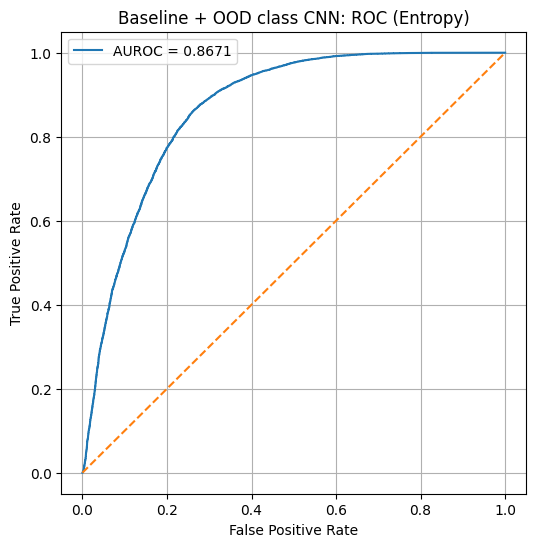

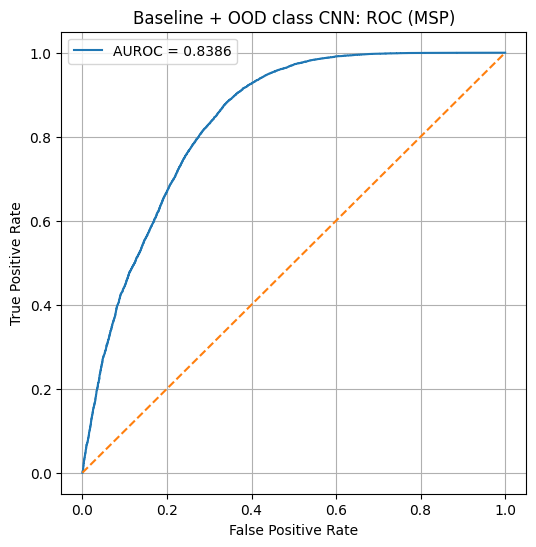

Baseline + OOD class CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8671
MSP AUROC: 0.8386


In [ ]:
basemodel_with_ood_id_results = evaluate_model(
    model=basemodel_OOD,
    loader=test_loader,
    device=device
)

basemodel_with_ood_ood_results = evaluate_model(
    model=basemodel_OOD,
    loader=svhn_loader,
    device=device
)
baseline_with_ood_metrics = evaluate_ood(
    id_probs=basemodel_with_ood_id_results["probs"],
    ood_probs=basemodel_with_ood_ood_results["probs"],
    model_name="Baseline + OOD class CNN"
)

Baseline + OOD class reject curves: 100%|██████████| 50/50 [00:00<00:00, 11476.15it/s]


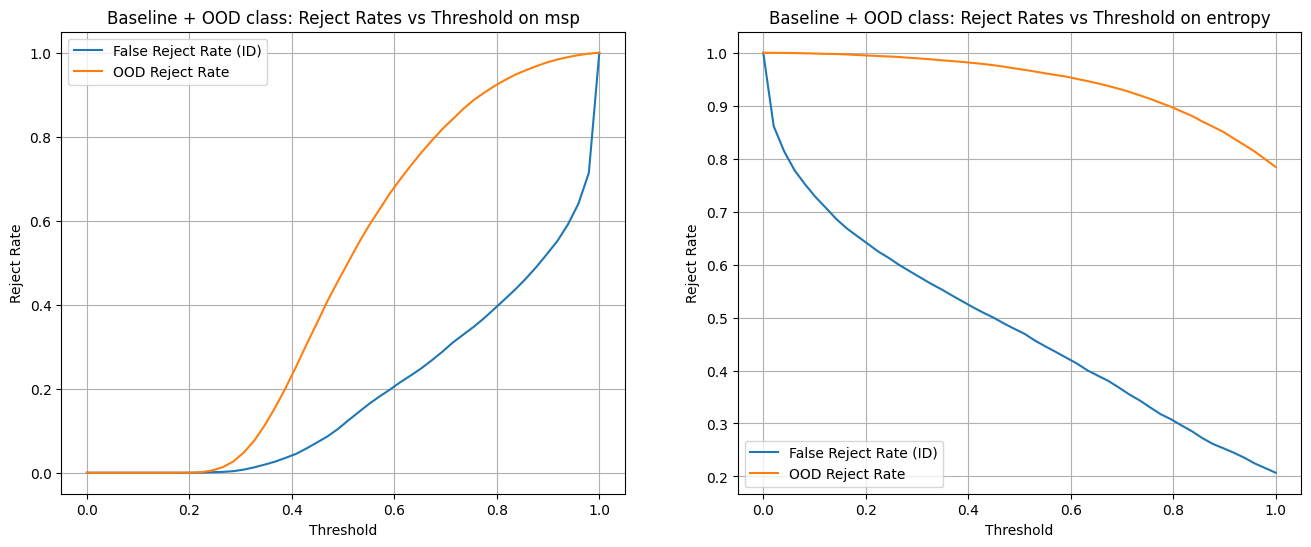

In [ ]:
plot_reject_curves(
    id_probs=basemodel_with_ood_id_results["probs"],
    ood_probs=basemodel_with_ood_ood_results["probs"],
    model_name="Baseline + OOD class"
)

###Gaussian NB with OOD

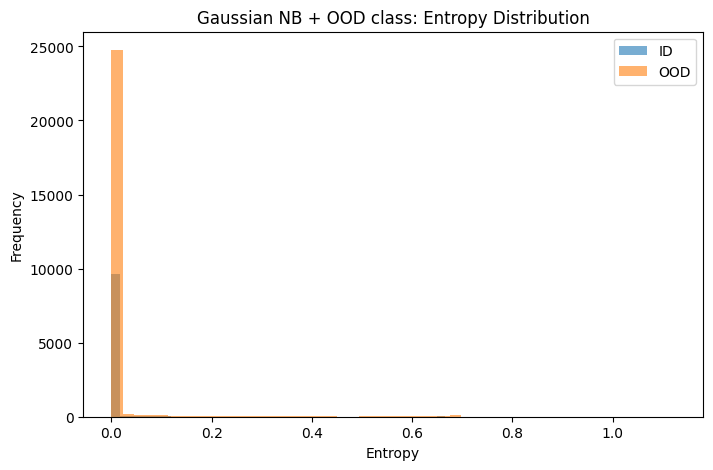

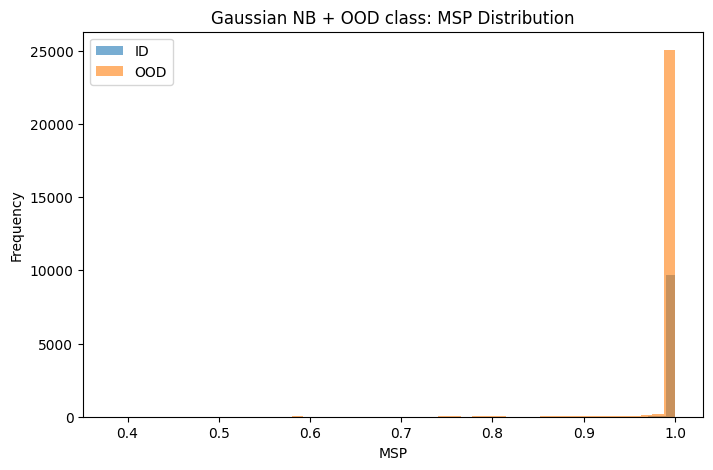

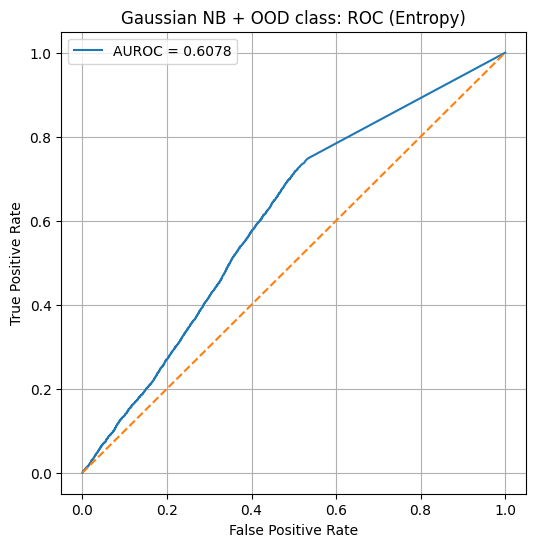

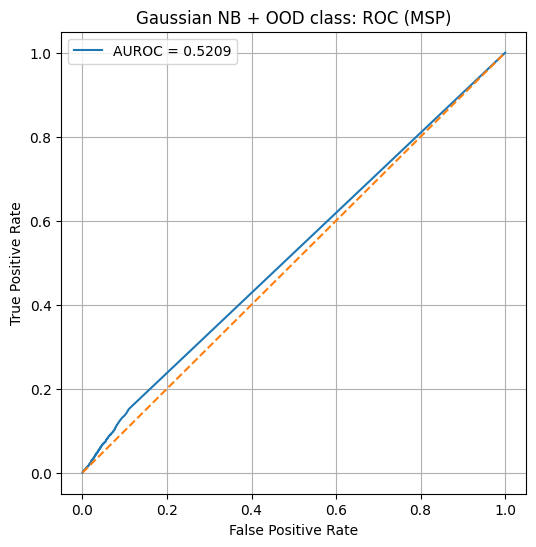

Gaussian NB + OOD class OOD Metrics
----------------------------------------
Entropy AUROC: 0.6078
MSP AUROC: 0.5209


In [ ]:
nb_with_ood_probs_id = torch.tensor(
    nb_OOD.predict_proba(X_test_on_OOD.numpy())
).float()

nb_with_ood_probs_ood = torch.tensor(
    nb_OOD.predict_proba(X_svhn_on_OOD.numpy())
).float()

nb_with_ood_metrics = evaluate_ood(
    id_probs=nb_with_ood_probs_id,
    ood_probs=nb_with_ood_probs_ood,
    model_name="Gaussian NB + OOD class"
)

Gaussian NB + OOD class reject curves: 100%|██████████| 50/50 [00:00<00:00, 11591.60it/s]


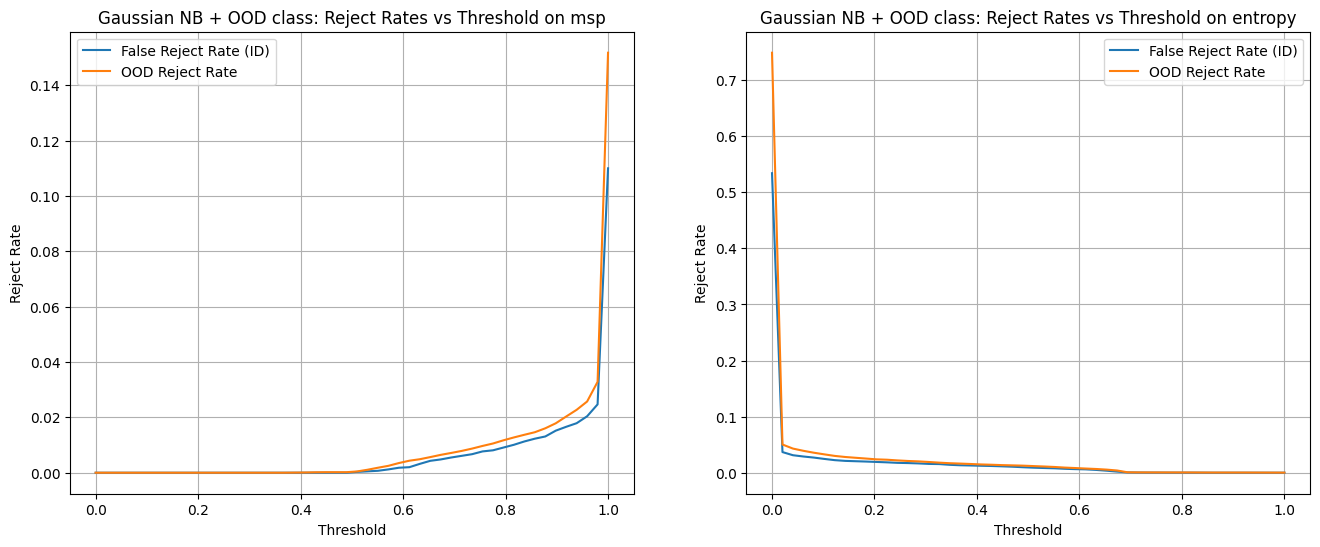

In [ ]:
plot_reject_curves(
    id_probs=nb_with_ood_probs_id,
    ood_probs=nb_with_ood_probs_ood,
    model_name="Gaussian NB + OOD class"
)

###Bayesian with OOD

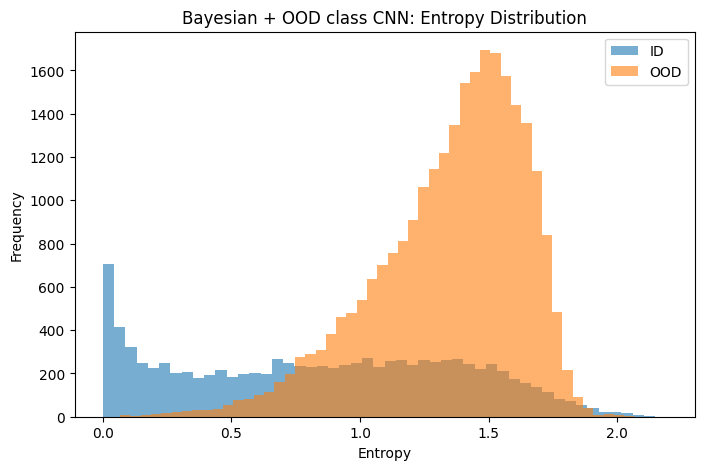

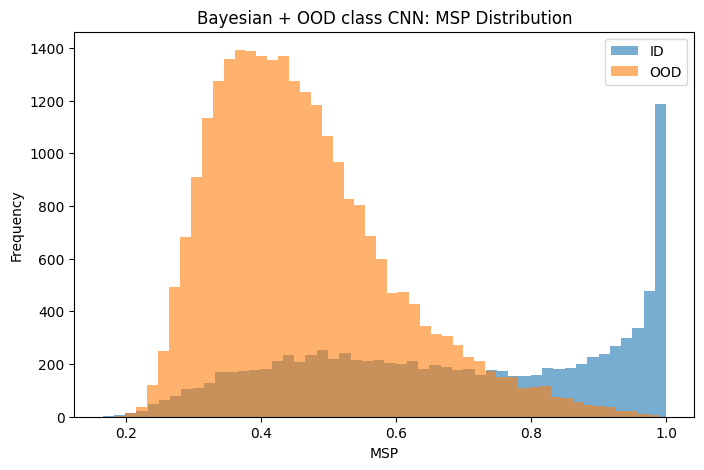

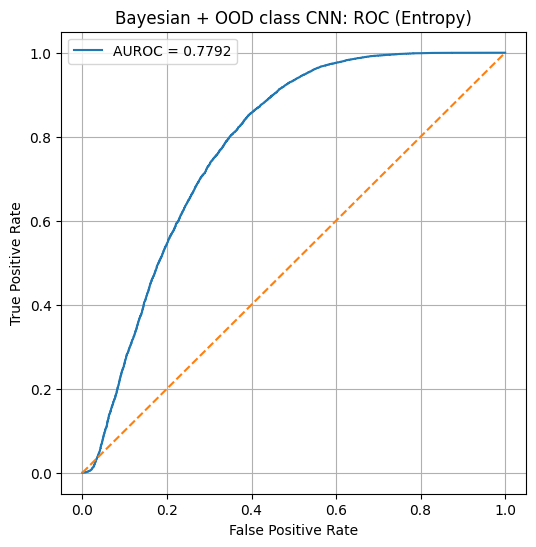

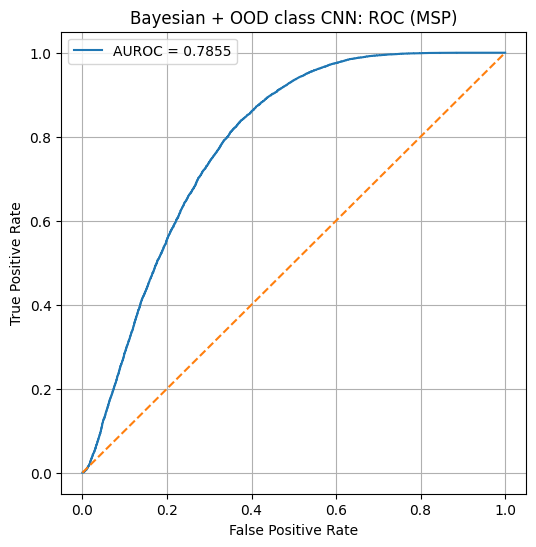

Bayesian + OOD class CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.7792
MSP AUROC: 0.7855


In [ ]:
bayes_with_ood_id_results = evaluate_model(
    model=bayes_OOD,
    loader=test_loader,
    device=device
)

bayes_with_ood_ood_results = evaluate_model(
    model=bayes_OOD,
    loader=svhn_loader,
    device=device
)
bayes_with_ood_metrics = evaluate_ood(
    id_probs=bayes_with_ood_id_results["probs"],
    ood_probs=bayes_with_ood_ood_results["probs"],
    model_name="Bayesian + OOD class CNN"
)

Baseline + OOD class reject curves: 100%|██████████| 50/50 [00:00<00:00, 9131.55it/s]


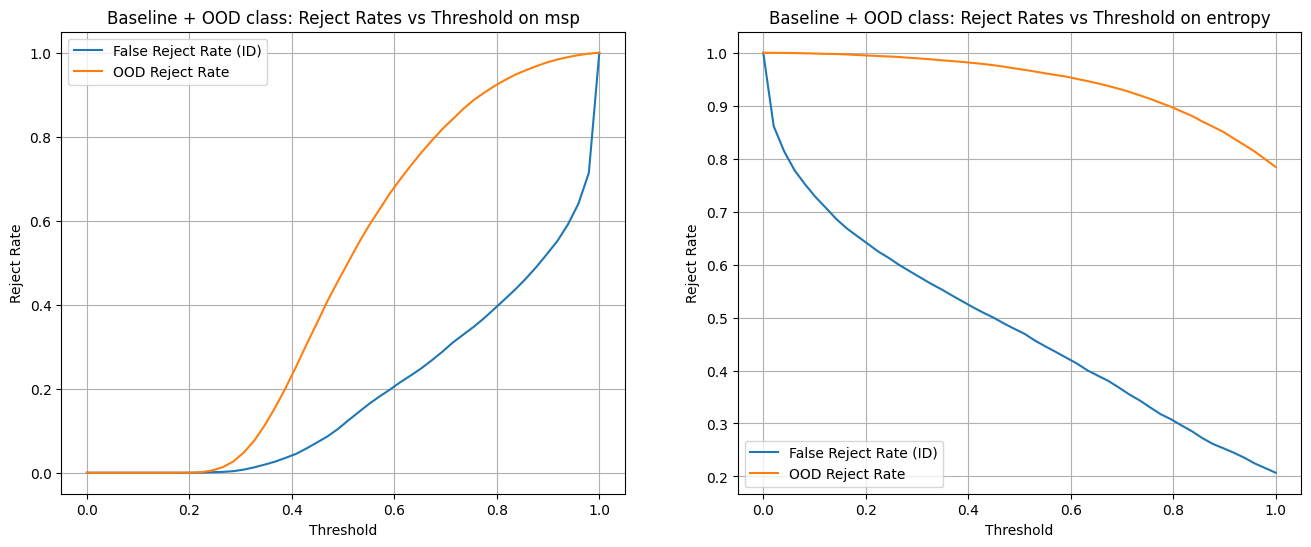

In [ ]:
plot_reject_curves(
    id_probs=basemodel_with_ood_id_results["probs"],
    ood_probs=basemodel_with_ood_ood_results["probs"],
    model_name="Baseline + OOD class"
)

#UNARY CLASSIFICATION

In [ ]:
class UnaryCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.backbone = FeatureCNN()

        self.head = nn.Linear(
            128 * 4 * 4,
            num_classes
        )

    def forward(self, x):

        feats = self.backbone(x)

        logits = self.head(feats)

        return logits

In [ ]:
model_unary = UnaryCNN(num_classes=10).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_unary.parameters(),
    lr=1e-3
)

fit(
    model=model_unary,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="onehot",
    use_ood=False
)

results_unary = evaluate_model(
    model_unary,
    test_loader,
    device
)

metrics_unary  = classification_metrics(
    results_unary["labels"].numpy(),
    results_unary["preds"].numpy()
)

print(metrics_unary["report"])


100%|██████████| 782/782 [00:12<00:00, 64.47it/s, acc=0.378, loss=0.208]


Epoch 1/10 | loss=0.2603 | acc=0.3781


100%|██████████| 782/782 [00:12<00:00, 64.04it/s, acc=0.559, loss=0.168]


Epoch 2/10 | loss=0.2037 | acc=0.5586


100%|██████████| 782/782 [00:12<00:00, 64.31it/s, acc=0.635, loss=0.13]


...

Epoch 8/10 | loss=0.1245 | acc=0.7707


100%|██████████| 782/782 [00:12<00:00, 64.64it/s, acc=0.786, loss=0.145]


Epoch 9/10 | loss=0.1187 | acc=0.7859


100%|██████████| 782/782 [00:11<00:00, 65.27it/s, acc=0.798, loss=0.117]


Epoch 10/10 | loss=0.1134 | acc=0.7983
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      1000
           1       0.83      0.87      0.85      1000
           2       0.65      0.65      0.65      1000
           3       0.61      0.53      0.56      1000
           4       0.69      0.70      0.70      1000
           5       0.66      0.66      0.66      1000
           6       0.85      0.81      0.82      1000
           7       0.82      0.77      0.80      1000
           8       0.83      0.87      0.85      1000
           9       0.77      0.85      0.81      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



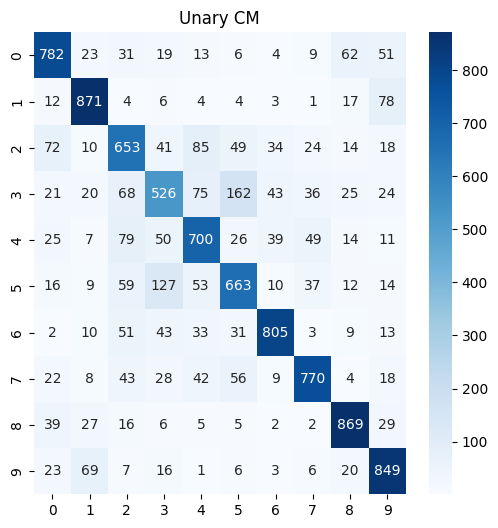

In [ ]:
plot_confusion_matrix(metrics_unary["confusion_matrix"], title="Unary CM")

##EVALUATION

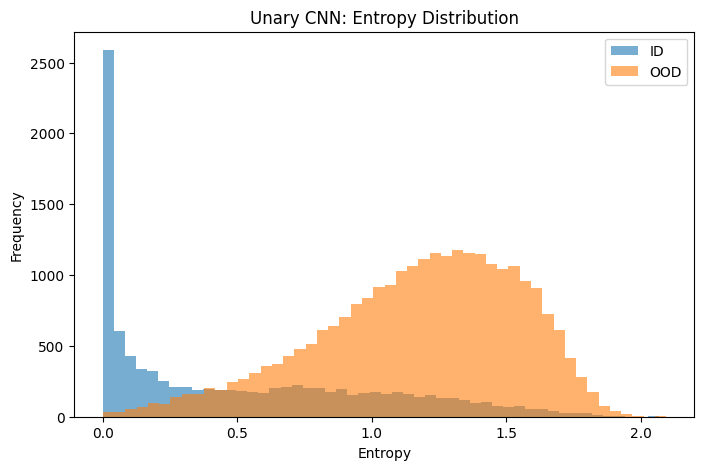

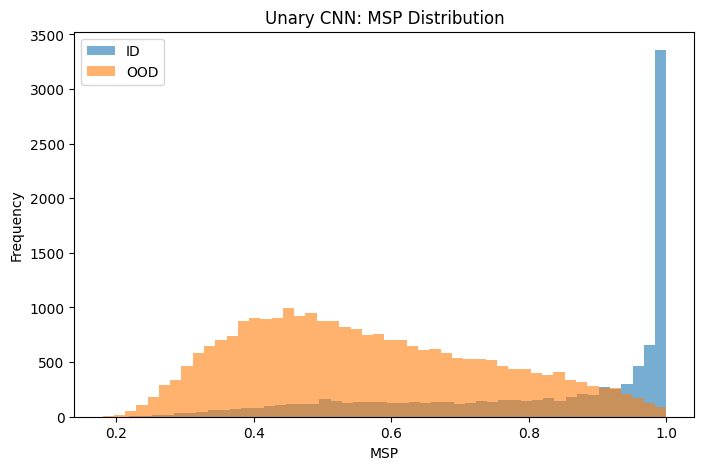

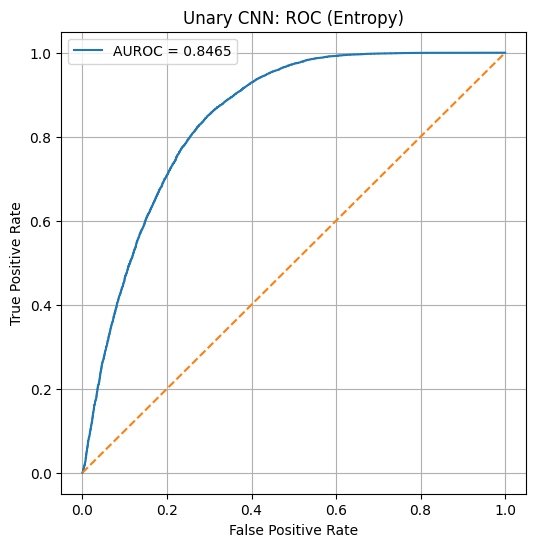

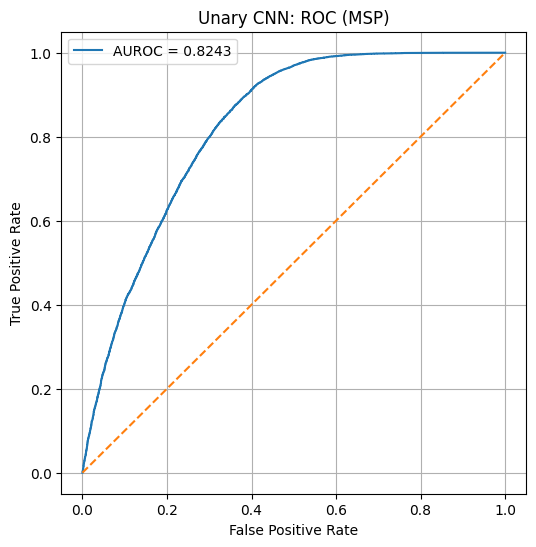

Unary CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8465
MSP AUROC: 0.8243


In [ ]:
unary_id_results = evaluate_model(
    model=model_unary,
    loader=test_loader,
    device=device
)

unary_ood_results = evaluate_model(
    model=model_unary,
    loader=svhn_loader,
    device=device
)
unary_metrics = evaluate_ood(
    id_probs=unary_id_results["probs"],
    ood_probs=unary_ood_results["probs"],
    model_name="Unary CNN"
)

Unary CNN reject curves: 100%|██████████| 50/50 [00:00<00:00, 12995.12it/s]


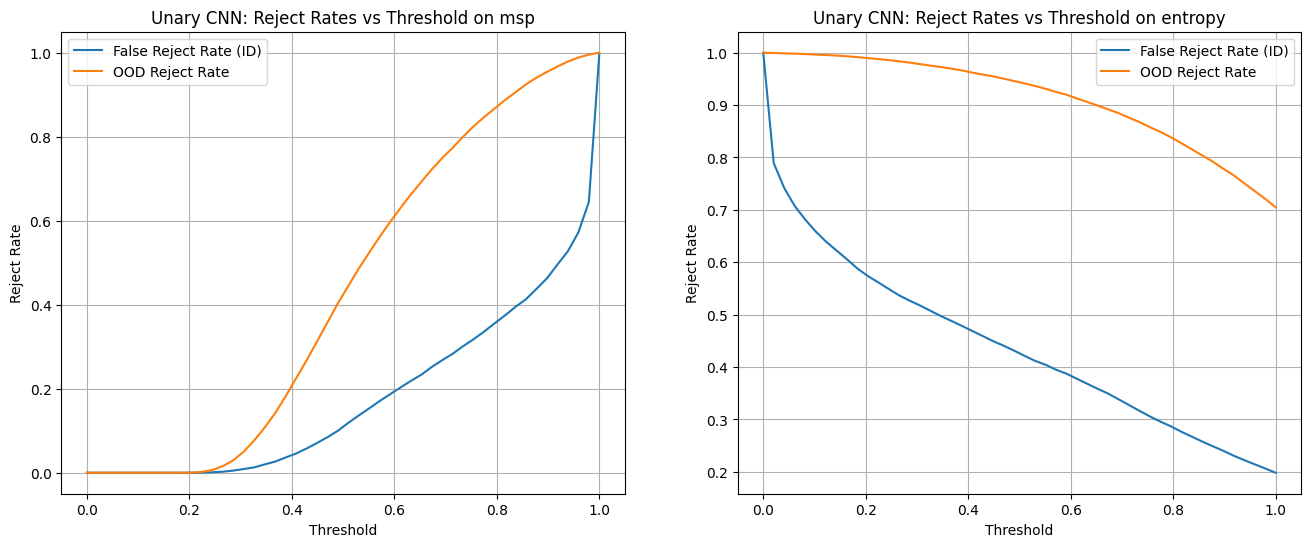

In [ ]:
plot_reject_curves(
    id_probs=unary_id_results["probs"],
    ood_probs=unary_ood_results["probs"],
    model_name="Unary CNN"
)

##Train more epochs

In [ ]:
steps, train_steps = 4, 10

fr_list_unary, orr_list_unary = progressive_training_evaluation(
    model_unary,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    svhn_loader,
    device,
    steps=steps,
    train_steps=train_steps,
    ood_mode=True,
    model_mode='onehot',
    ood_ratio=0.1,
    score_mode="entropy"
)




100%|██████████| 782/782 [00:12<00:00, 62.49it/s, acc=0.811, loss=0.0383]


Epoch 1/10 | loss=0.0985 | acc=0.8110


100%|██████████| 782/782 [00:12<00:00, 62.33it/s, acc=0.819, loss=0.131]


Epoch 2/10 | loss=0.0949 | acc=0.8193


100%|██████████| 782/782 [00:12<00:00, 62.67it/s, acc=0.83, loss=0.0992]


...

Epoch 9/10 | loss=0.0258 | acc=0.9775


100%|██████████| 782/782 [00:12<00:00, 61.68it/s, acc=0.977, loss=0.0145]


Epoch 10/10 | loss=0.0255 | acc=0.9767


Model reject curves: 100%|██████████| 50/50 [00:00<00:00, 9243.44it/s]

step: 4/4: 
	FR = 0.235614
	ORR = 0.5314074984634296


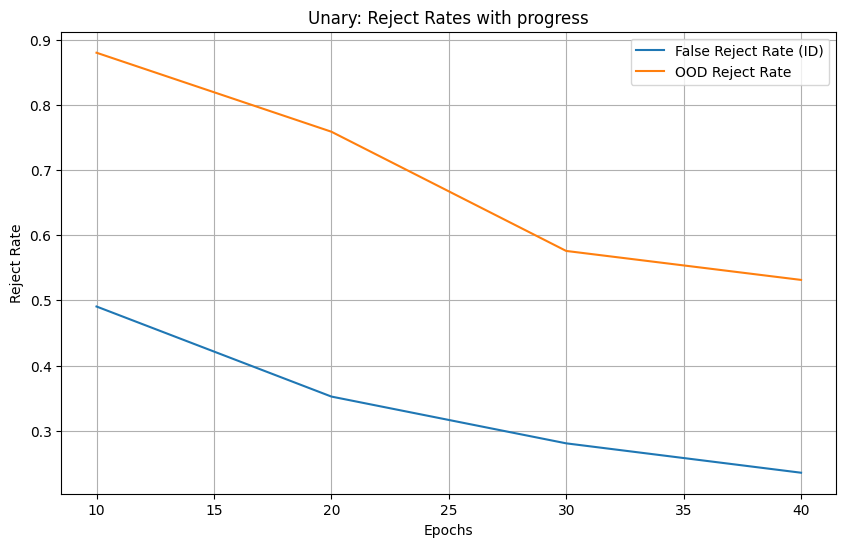

In [ ]:
epochs = train_steps, (steps+1)*train_steps, train_steps
plot_reject_rate_by_epochs(epochs, fr_list_unary, orr_list_unary, model="Unary")

###Evaluation after additional epochs

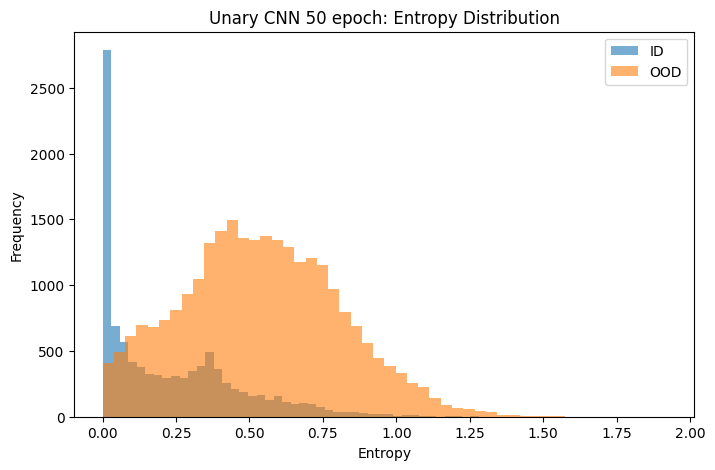

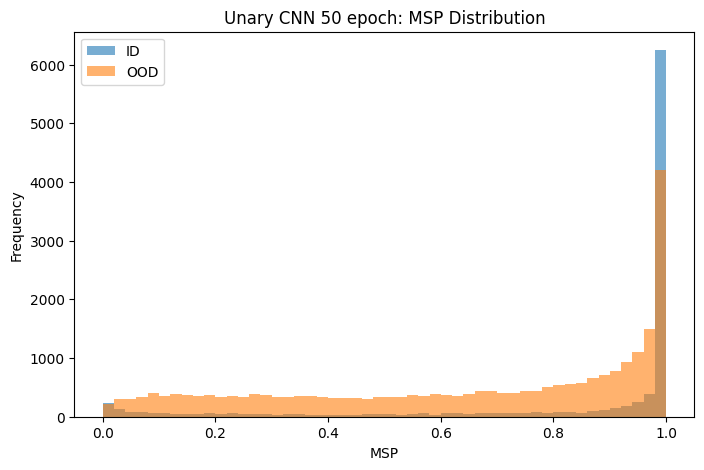

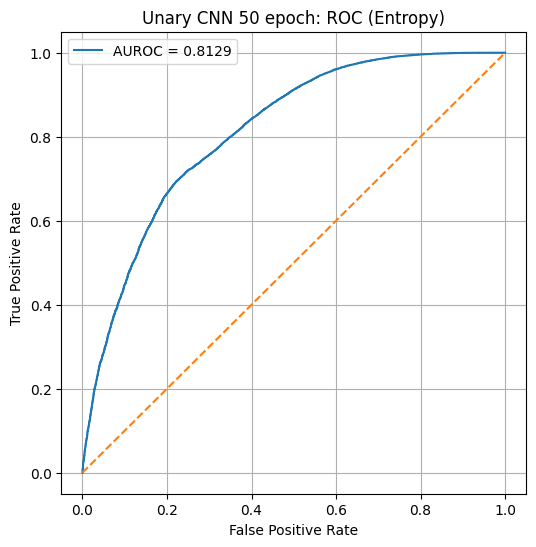

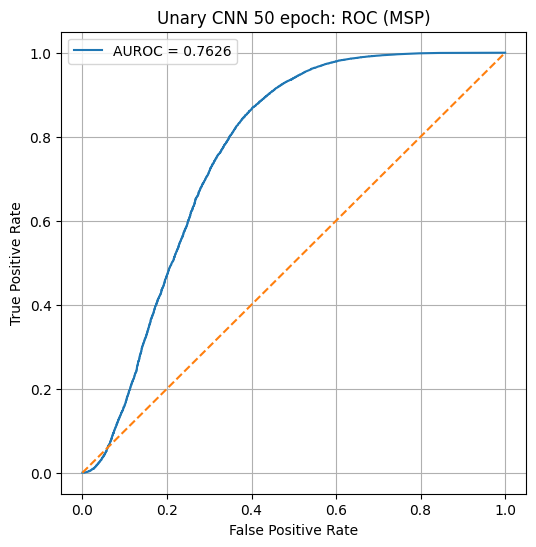

Unary CNN 50 epoch OOD Metrics
----------------------------------------
Entropy AUROC: 0.8129
MSP AUROC: 0.7626


In [ ]:
unary_id_results_50e = evaluate_model(
    model=model_unary,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_ood_results_50e = evaluate_model(
    model=model_unary,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_metrics_50e = evaluate_ood(
    id_probs=unary_id_results_50e["probs"],
    ood_probs=unary_ood_results_50e["probs"],
    model_name="Unary CNN 50 epoch"
)

Unary CNN 50 epoch reject curves: 100%|██████████| 50/50 [00:00<00:00, 12577.38it/s]


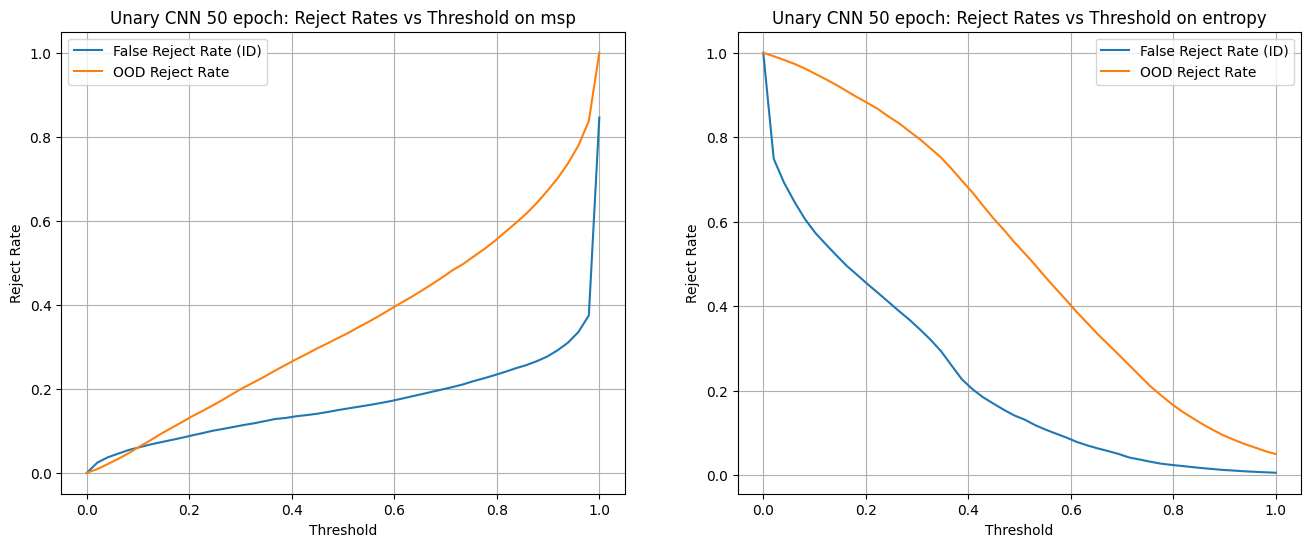

In [ ]:
plot_reject_curves(
    id_probs=unary_id_results_50e["probs"],
    ood_probs=unary_ood_results_50e["probs"],
    model_name="Unary CNN 50 epoch"
)

#UNARY MODEL WITH OOD

In [ ]:
model_unary_ood = UnaryCNN(num_classes=10).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_unary_ood.parameters(),
    lr=1e-3
)

fit(
    model=model_unary_ood,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="onehot",
    use_ood=True,
    ood_ratio = ood_ratio
)

results_unary_ood = evaluate_model(
    model_unary_ood,
    test_loader,
    device,
    mode="onehot"
)

metrics_unary_ood = classification_metrics(
    results_unary_ood["labels"].numpy(),
    results_unary_ood["preds"].numpy()
)

print(metrics_unary_ood["report"])


100%|██████████| 782/782 [00:14<00:00, 55.27it/s, acc=0.356, loss=0.115]


Epoch 1/10 | loss=0.1366 | acc=0.3565


100%|██████████| 782/782 [00:14<00:00, 54.71it/s, acc=0.534, loss=0.0781]


Epoch 2/10 | loss=0.1057 | acc=0.5335


100%|██████████| 782/782 [00:14<00:00, 53.35it/s, acc=0.613, loss=0.0758]


...

Epoch 8/10 | loss=0.0619 | acc=0.7732


100%|██████████| 782/782 [00:14<00:00, 53.55it/s, acc=0.79, loss=0.0652]


Epoch 9/10 | loss=0.0587 | acc=0.7895


100%|██████████| 782/782 [00:14<00:00, 53.36it/s, acc=0.802, loss=0.0325]


Epoch 10/10 | loss=0.0557 | acc=0.8016
              precision    recall  f1-score   support

           0       0.73      0.82      0.77      1000
           1       0.83      0.89      0.86      1000
           2       0.78      0.53      0.63      1000
           3       0.49      0.68      0.57      1000
           4       0.72      0.68      0.70      1000
           5       0.65      0.64      0.64      1000
           6       0.84      0.76      0.80      1000
           7       0.83      0.75      0.79      1000
           8       0.82      0.88      0.85      1000
           9       0.84      0.78      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



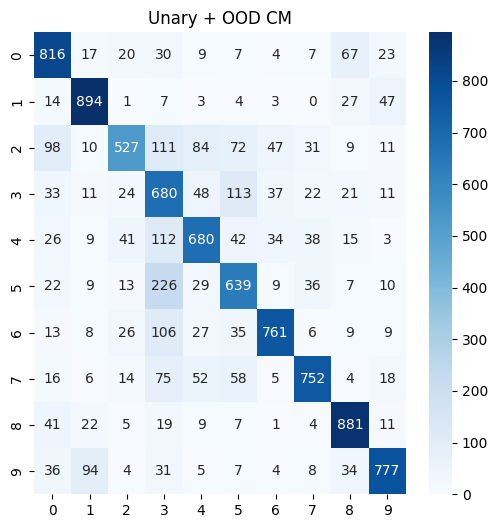

In [ ]:
plot_confusion_matrix(metrics_unary_ood["confusion_matrix"], title="Unary + OOD CM")

##EVALUATION

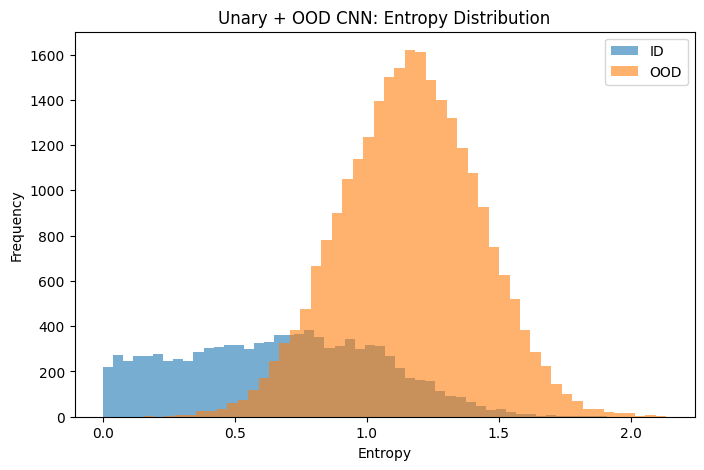

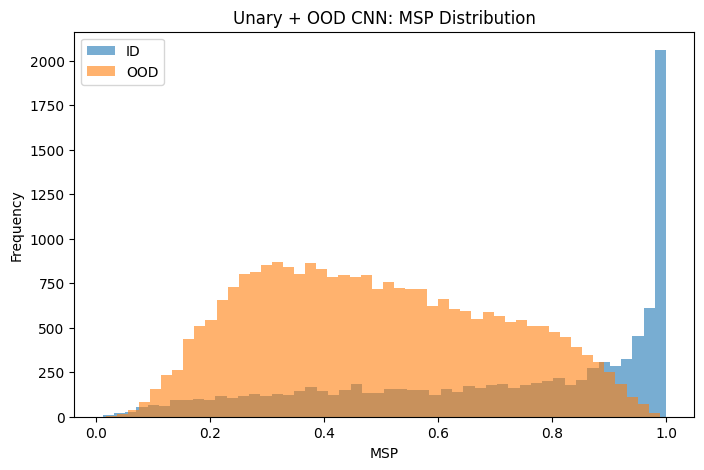

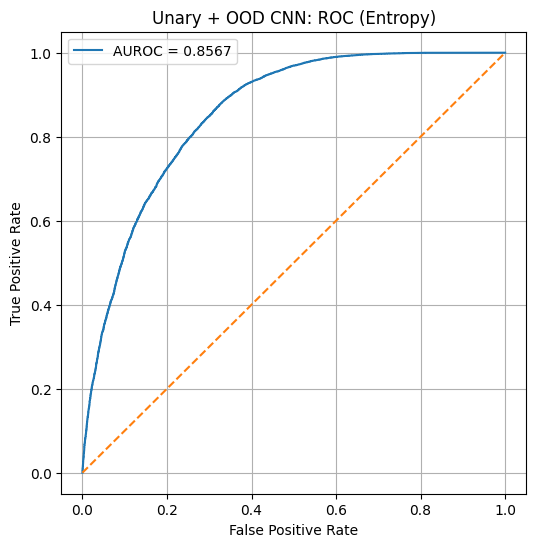

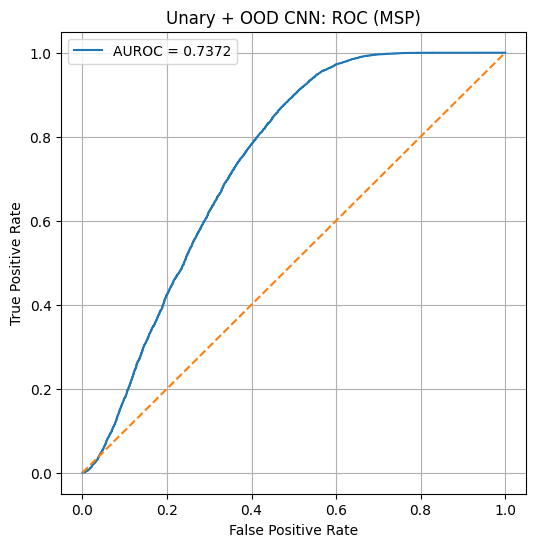

Unary + OOD CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8567
MSP AUROC: 0.7372


In [ ]:
unary_ood_id_results = evaluate_model(
    model=model_unary_ood,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_ood_ood_results = evaluate_model(
    model=model_unary_ood,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_ood_metrics = evaluate_ood(
    id_probs=unary_ood_id_results["probs"],
    ood_probs=unary_ood_ood_results["probs"],
    model_name="Unary + OOD CNN"
)

Unary + OOD CNN reject curves: 100%|██████████| 50/50 [00:00<00:00, 11284.72it/s]


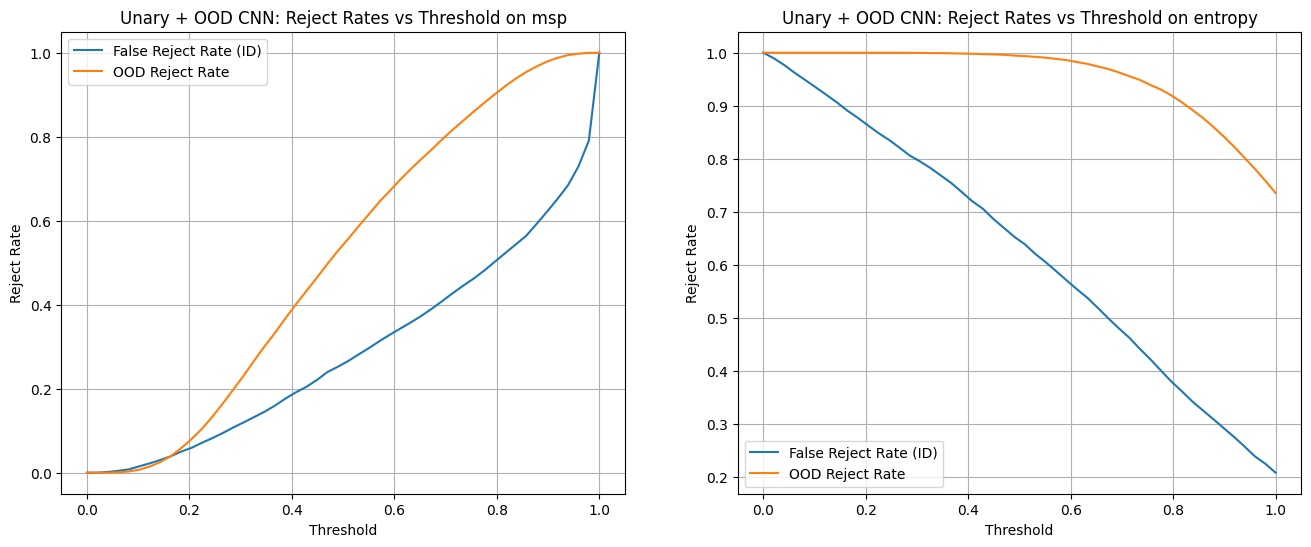

In [ ]:
plot_reject_curves(
    id_probs=unary_ood_id_results["probs"],
    ood_probs=unary_ood_ood_results["probs"],
    model_name="Unary + OOD CNN"
)

## Train more epochs

In [ ]:
steps, train_steps = 4, 10

fr_list_unary_ood, orr_list_unary_ood = progressive_training_evaluation(
    model_unary_ood,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    svhn_loader,
    device,
    steps=steps,
    train_steps=train_steps,
    ood_mode=True,
    model_mode='onehot',
    ood_ratio=0.1,
    score_mode="entropy"
)




100%|██████████| 782/782 [00:12<00:00, 62.37it/s, acc=0.802, loss=0.0314]


Epoch 1/10 | loss=0.1023 | acc=0.8025


100%|██████████| 782/782 [00:12<00:00, 62.53it/s, acc=0.824, loss=0.141]


Epoch 2/10 | loss=0.0931 | acc=0.8236


100%|██████████| 782/782 [00:12<00:00, 61.88it/s, acc=0.84, loss=0.109]


...

Epoch 9/10 | loss=0.0196 | acc=0.9861


100%|██████████| 782/782 [00:12<00:00, 61.14it/s, acc=0.986, loss=0.00453]


Epoch 10/10 | loss=0.0197 | acc=0.9857


Model reject curves: 100%|██████████| 50/50 [00:00<00:00, 10377.83it/s]

step: 4/4: 
	FR = 0.175004
	ORR = 0.44260525507068216


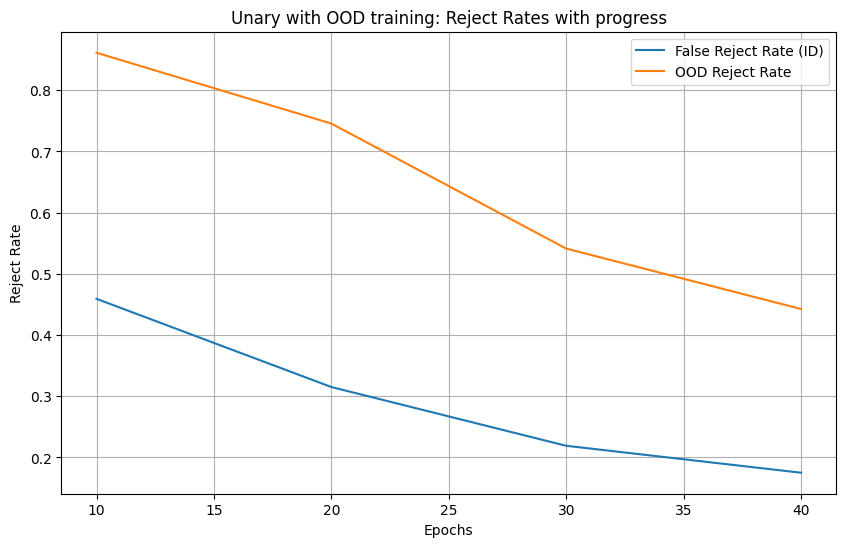

In [ ]:
epochs = train_steps, (steps+1)*train_steps, train_steps
plot_reject_rate_by_epochs(epochs, fr_list_unary_ood, orr_list_unary_ood, model="Unary with OOD training")

###Evaluation after additional epochs

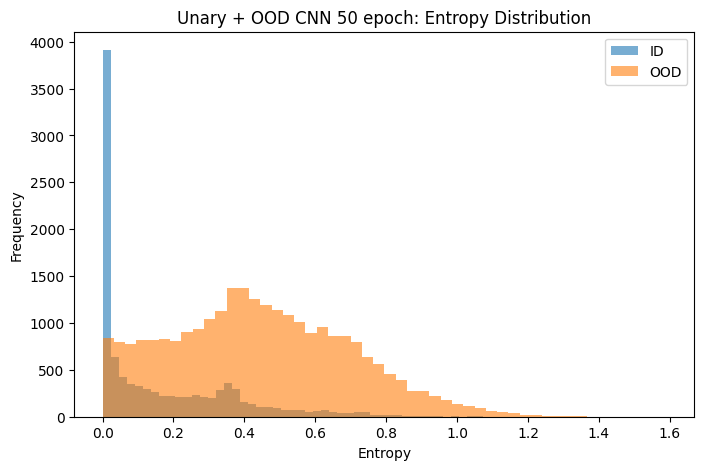

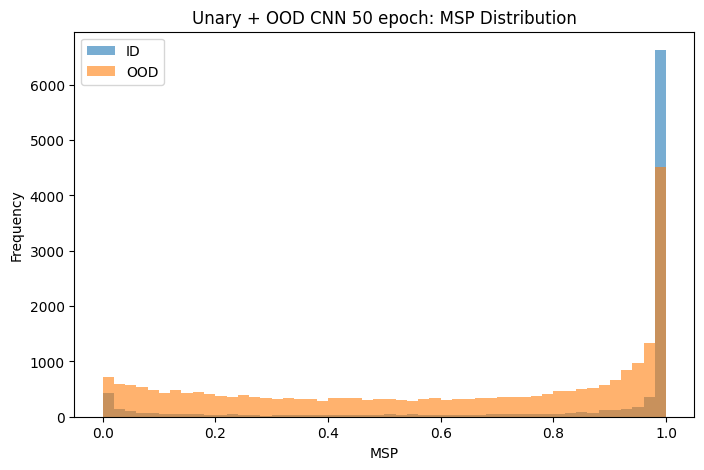

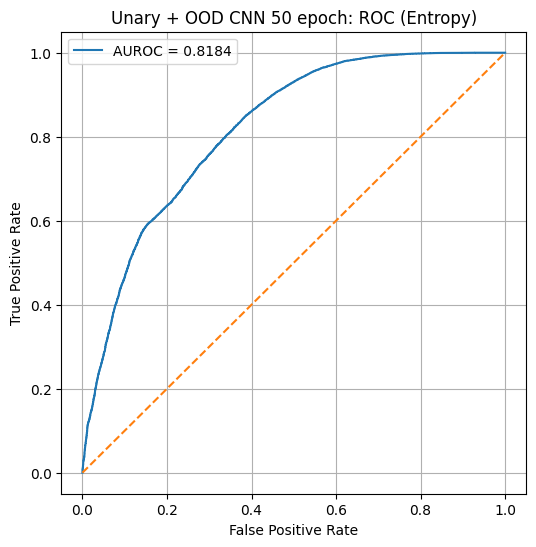

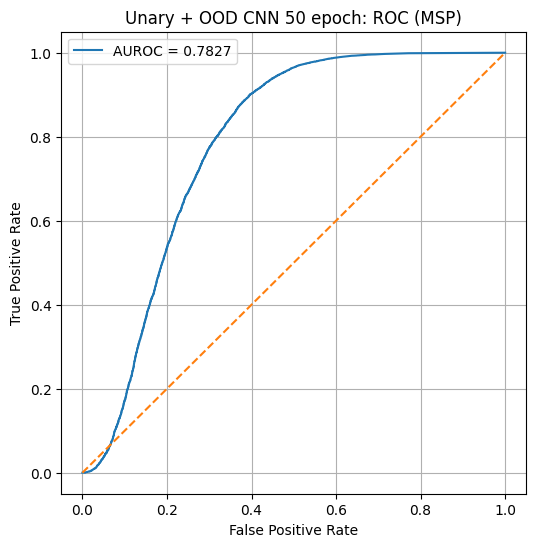

Unary + OOD CNN 50 epoch OOD Metrics
----------------------------------------
Entropy AUROC: 0.8184
MSP AUROC: 0.7827


In [ ]:
unary_ood_id_results_50e = evaluate_model(
    model=model_unary_ood,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_ood_ood_results_50e = evaluate_model(
    model=model_unary_ood,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_ood_metrics_50e = evaluate_ood(
    id_probs=unary_ood_id_results_50e["probs"],
    ood_probs=unary_ood_ood_results_50e["probs"],
    model_name="Unary + OOD CNN 50 epoch"
)

Unary + OOD CNN 50 epoch reject curves: 100%|██████████| 50/50 [00:00<00:00, 11262.30it/s]


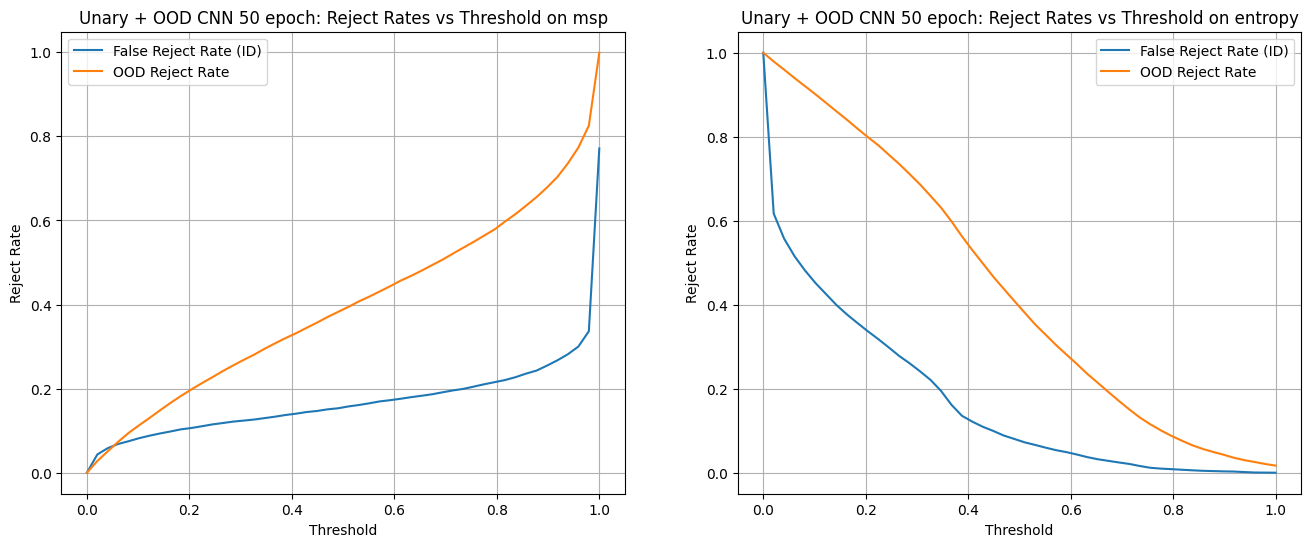

In [ ]:
plot_reject_curves(
    id_probs=unary_ood_id_results_50e["probs"],
    ood_probs=unary_ood_ood_results_50e["probs"],
    model_name="Unary + OOD CNN 50 epoch"
)

#UNARY REGULARIZE

In [ ]:
class UnaryCNNRegularized(nn.Module):

    def __init__(
        self,
        num_classes=10,
        dropout=0.5
    ):
        super().__init__()

        self.backbone = FeatureCNN()

        self.dropout = nn.Dropout(
            dropout
        )

        self.head = nn.Linear(
            128 * 4 * 4,
            num_classes
        )

    def forward(self, x):

        feats = self.backbone(x)

        feats = self.dropout(feats)

        logits = self.head(feats)

        return logits

In [ ]:
model_unary_reg = UnaryCNNRegularized(
    num_classes=10,
    dropout=0.5
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_unary_reg.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

fit(
    model=model_unary_reg,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="onehot",
    use_ood=False
)

results_unary_reg = evaluate_model(
    model_unary_reg,
    test_loader,
    device
)

metrics_unary_reg  = classification_metrics(
    results_unary_reg["labels"].numpy(),
    results_unary_reg["preds"].numpy()
)

print(metrics_unary_reg["report"])

100%|██████████| 782/782 [00:12<00:00, 63.60it/s, acc=0.359, loss=0.197]


Epoch 1/10 | loss=0.2658 | acc=0.3588


100%|██████████| 782/782 [00:12<00:00, 64.04it/s, acc=0.509, loss=0.2]


Epoch 2/10 | loss=0.2187 | acc=0.5095


100%|██████████| 782/782 [00:12<00:00, 62.89it/s, acc=0.57, loss=0.184]


...

Epoch 8/10 | loss=0.1567 | acc=0.6876


100%|██████████| 782/782 [00:12<00:00, 62.65it/s, acc=0.701, loss=0.15]


Epoch 9/10 | loss=0.1525 | acc=0.7006


100%|██████████| 782/782 [00:12<00:00, 63.19it/s, acc=0.708, loss=0.127]


Epoch 10/10 | loss=0.1493 | acc=0.7077
              precision    recall  f1-score   support

           0       0.83      0.71      0.76      1000
           1       0.85      0.87      0.86      1000
           2       0.72      0.49      0.59      1000
           3       0.52      0.57      0.55      1000
           4       0.66      0.65      0.66      1000
           5       0.62      0.68      0.65      1000
           6       0.78      0.81      0.79      1000
           7       0.73      0.81      0.77      1000
           8       0.83      0.85      0.84      1000
           9       0.79      0.84      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



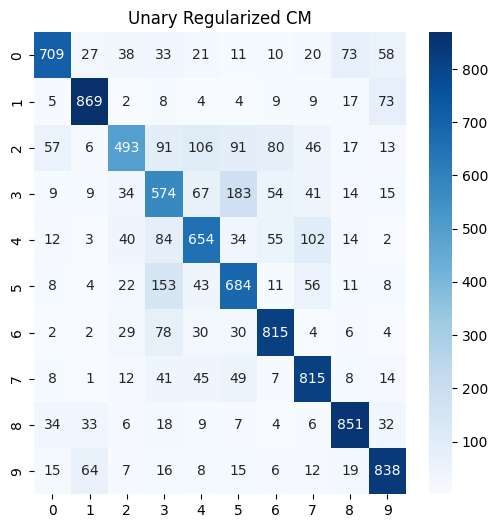

In [ ]:
plot_confusion_matrix(metrics_unary_reg["confusion_matrix"], title="Unary Regularized CM")

##Evaluation

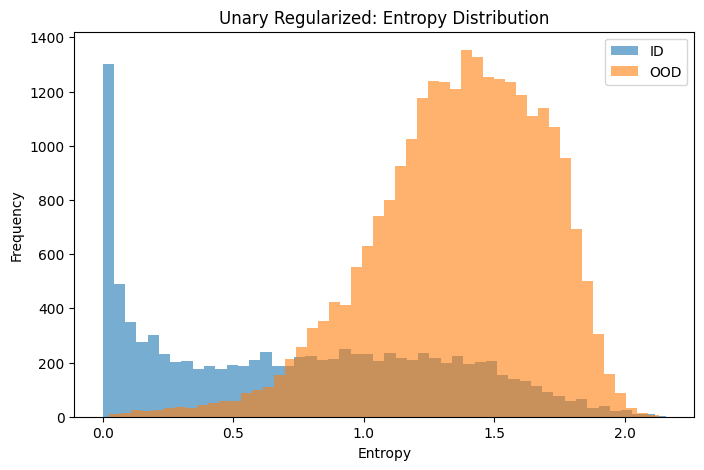

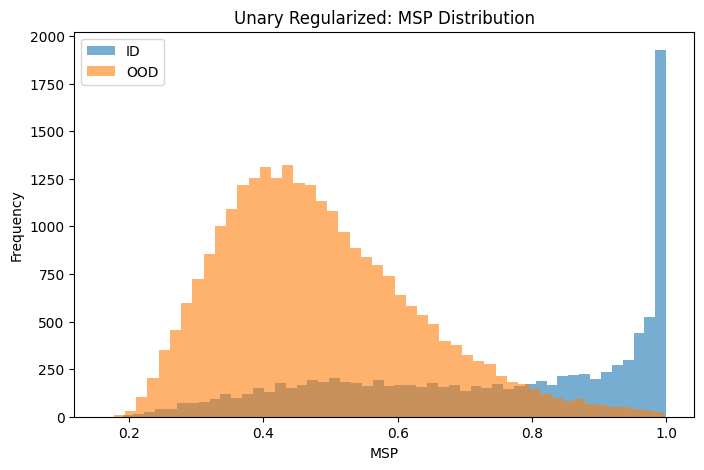

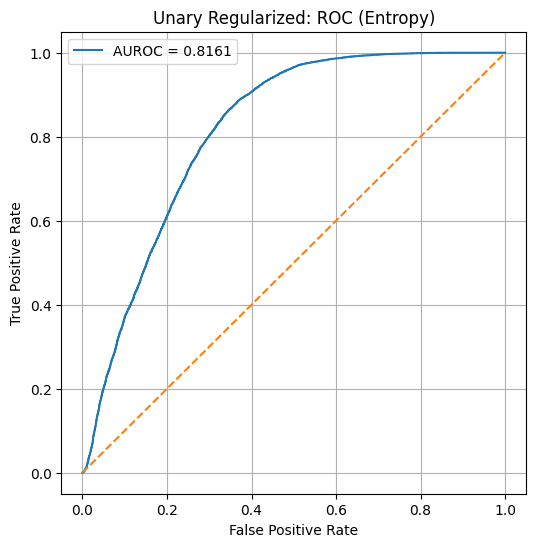

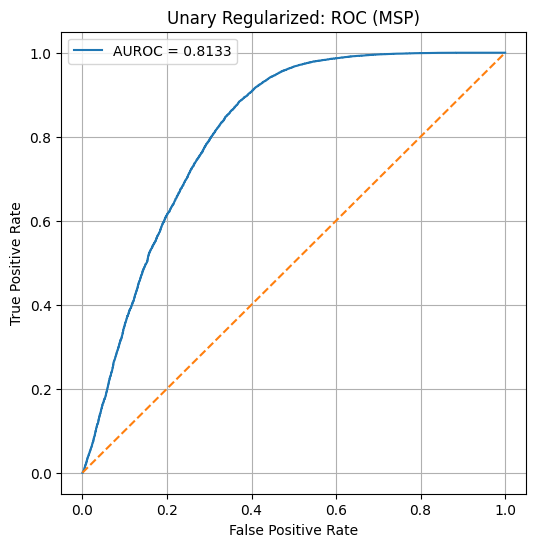

Unary Regularized OOD Metrics
----------------------------------------
Entropy AUROC: 0.8161
MSP AUROC: 0.8133


In [ ]:
unary_reg_id_results = evaluate_model(
    model=model_unary_reg,
    loader=test_loader,
    device=device
)

unary_reg_ood_results = evaluate_model(
    model=model_unary_reg,
    loader=svhn_loader,
    device=device
)
unary_reg_metrics = evaluate_ood(
    id_probs=unary_reg_id_results["probs"],
    ood_probs=unary_reg_ood_results["probs"],
    model_name="Unary Regularized"
)

Unary Regularized reject curves: 100%|██████████| 50/50 [00:00<00:00, 11338.41it/s]


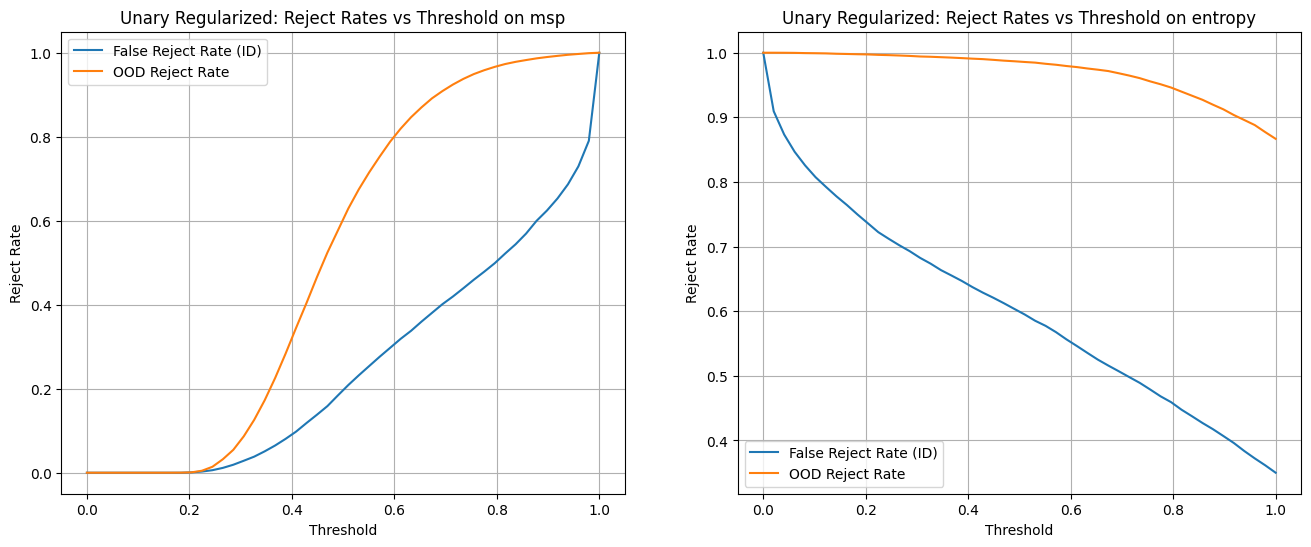

In [ ]:
plot_reject_curves(
    id_probs=unary_reg_id_results["probs"],
    ood_probs=unary_reg_ood_results["probs"],
    model_name="Unary Regularized"
)

## Train more epochs

In [ ]:
steps, train_steps = 4, 10

fr_list_unary_reg, orr_list_unary_reg = progressive_training_evaluation(
    model_unary_reg,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    svhn_loader,
    device,
    steps=steps,
    train_steps=train_steps,
    ood_mode=False,
    model_mode='onehot',
    ood_ratio=0.1,
    score_mode="entropy"
)



100%|██████████| 782/782 [00:12<00:00, 63.79it/s, acc=0.716, loss=0.151]


Epoch 1/10 | loss=0.1457 | acc=0.7155


100%|██████████| 782/782 [00:12<00:00, 62.33it/s, acc=0.723, loss=0.102]


Epoch 2/10 | loss=0.1431 | acc=0.7233


100%|██████████| 782/782 [00:12<00:00, 64.12it/s, acc=0.727, loss=0.154]


...

Epoch 9/10 | loss=0.1094 | acc=0.8010


100%|██████████| 782/782 [00:12<00:00, 60.17it/s, acc=0.802, loss=0.146]


Epoch 10/10 | loss=0.1089 | acc=0.8018


Model reject curves: 100%|██████████| 50/50 [00:00<00:00, 9061.71it/s]

step: 4/4: 
	FR = 0.6447700000000001
	ORR = 0.9799462200368777


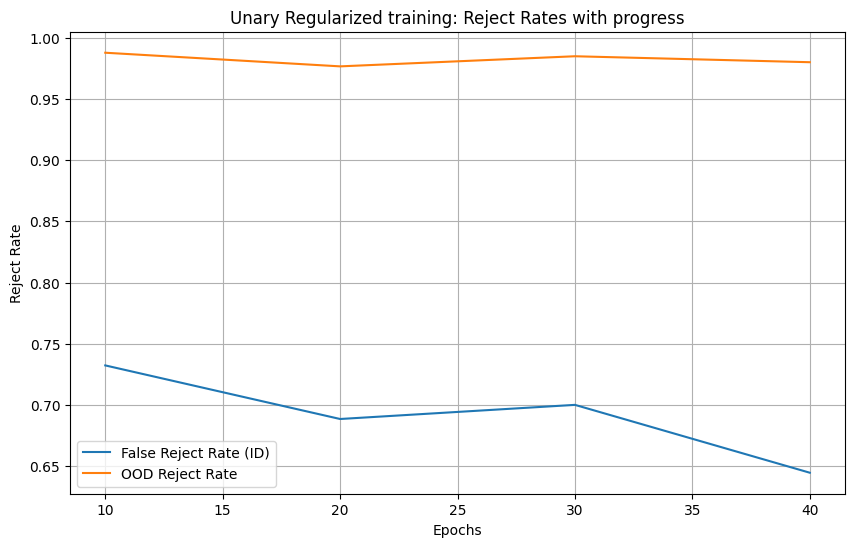

In [ ]:
epochs = train_steps, (steps+1)*train_steps, train_steps
plot_reject_rate_by_epochs(epochs, fr_list_unary_reg, orr_list_unary_reg, model="Unary Regularized training")

###Evaluation after additional epochs

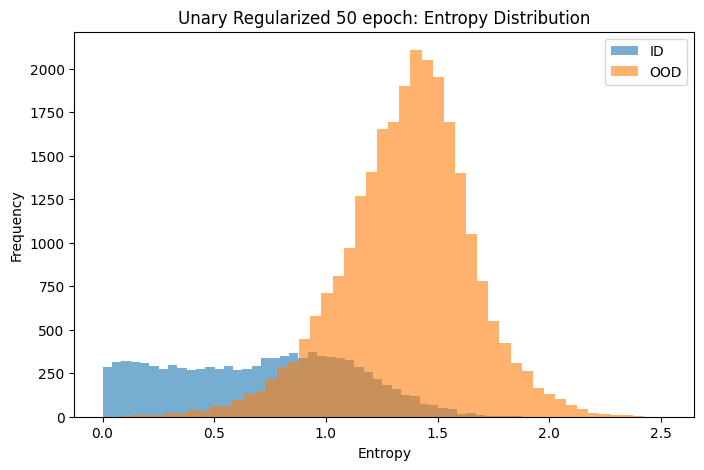

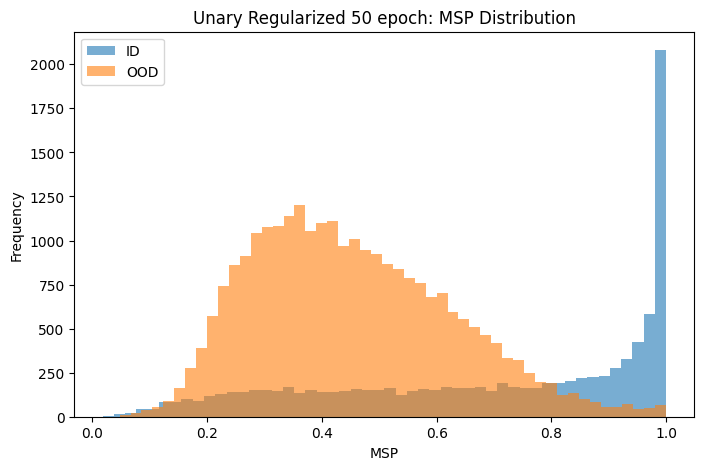

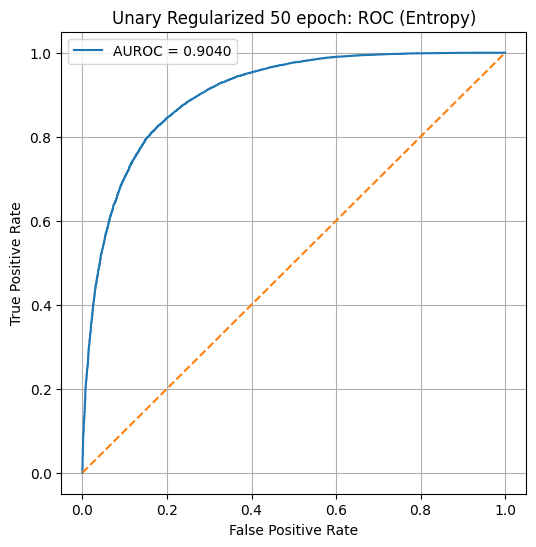

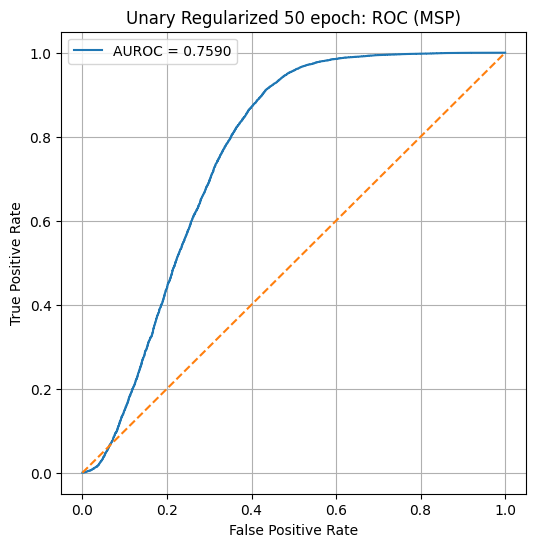

Unary Regularized 50 epoch OOD Metrics
----------------------------------------
Entropy AUROC: 0.9040
MSP AUROC: 0.7590


In [ ]:
unary_reg_id_results_50e = evaluate_model(
    model=model_unary_reg,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_reg_ood_results_50e = evaluate_model(
    model=model_unary_reg,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_reg_metrics_50e = evaluate_ood(
    id_probs=unary_reg_id_results_50e["probs"],
    ood_probs=unary_reg_ood_results_50e["probs"],
    model_name="Unary Regularized 50 epoch"
)

Unary Regularized 50 epoch reject curves: 100%|██████████| 50/50 [00:00<00:00, 9208.13it/s]


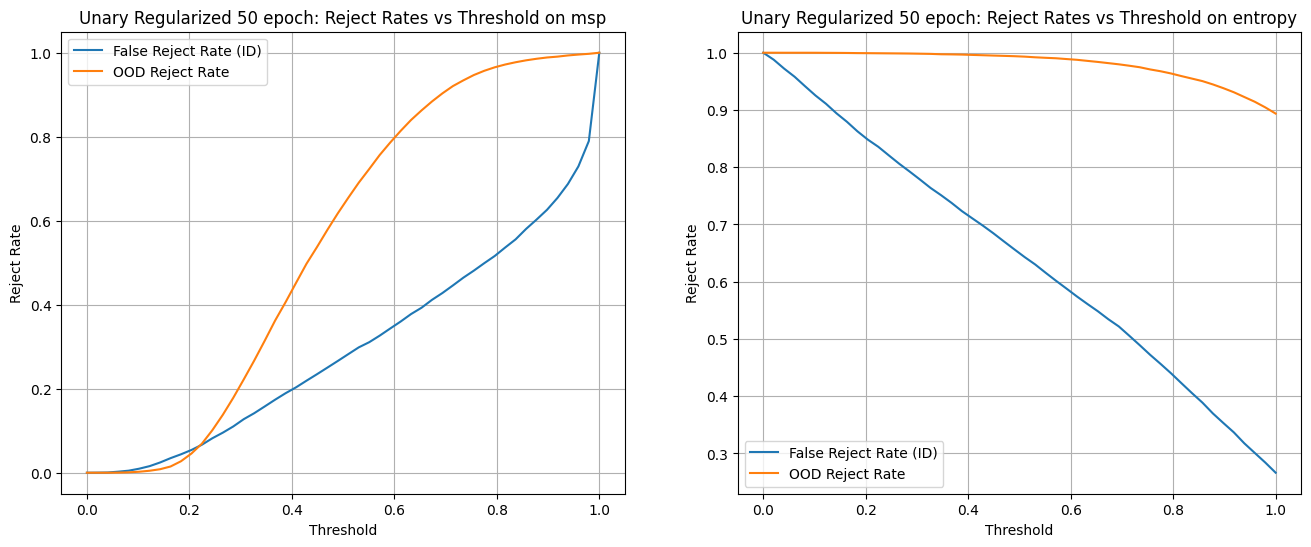

In [ ]:
plot_reject_curves(
    id_probs=unary_reg_id_results_50e["probs"],
    ood_probs=unary_reg_ood_results_50e["probs"],
    model_name="Unary Regularized 50 epoch"
)

#UNARY WITH OOD REGULARIZE

In [ ]:
model_unary_reg_ood = UnaryCNNRegularized(
    num_classes=10,
    dropout=0.5
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_unary_reg_ood.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

fit(
    model=model_unary_reg_ood,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="onehot",
    use_ood=True
)

results_unary_reg_ood = evaluate_model(
    model_unary_reg_ood,
    test_loader,
    device
)

metrics_unary_reg_ood = classification_metrics(
    results_unary_reg_ood["labels"].numpy(),
    results_unary_reg_ood["preds"].numpy()
)

print(metrics_unary_reg_ood["report"])

100%|██████████| 782/782 [00:14<00:00, 54.60it/s, acc=0.34, loss=0.126]


Epoch 1/10 | loss=0.1386 | acc=0.3400


100%|██████████| 782/782 [00:14<00:00, 54.39it/s, acc=0.489, loss=0.106]


Epoch 2/10 | loss=0.1132 | acc=0.4889


100%|██████████| 782/782 [00:14<00:00, 53.27it/s, acc=0.543, loss=0.0922]


...

Epoch 8/10 | loss=0.0823 | acc=0.6730


100%|██████████| 782/782 [00:14<00:00, 53.90it/s, acc=0.68, loss=0.0688]


Epoch 9/10 | loss=0.0802 | acc=0.6803


100%|██████████| 782/782 [00:14<00:00, 53.54it/s, acc=0.686, loss=0.0581]


Epoch 10/10 | loss=0.0789 | acc=0.6864
              precision    recall  f1-score   support

           0       0.81      0.65      0.72      1000
           1       0.91      0.75      0.83      1000
           2       0.51      0.67      0.58      1000
           3       0.50      0.58      0.54      1000
           4       0.65      0.67      0.66      1000
           5       0.72      0.50      0.59      1000
           6       0.73      0.83      0.78      1000
           7       0.90      0.62      0.73      1000
           8       0.74      0.90      0.81      1000
           9       0.76      0.85      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.72      0.70      0.70     10000
weighted avg       0.72      0.70      0.70     10000



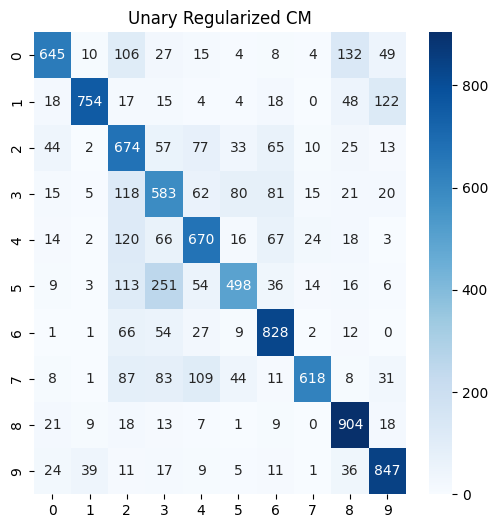

In [ ]:
plot_confusion_matrix(metrics_unary_reg_ood["confusion_matrix"], title="Unary Regularized CM")

##Evaluation

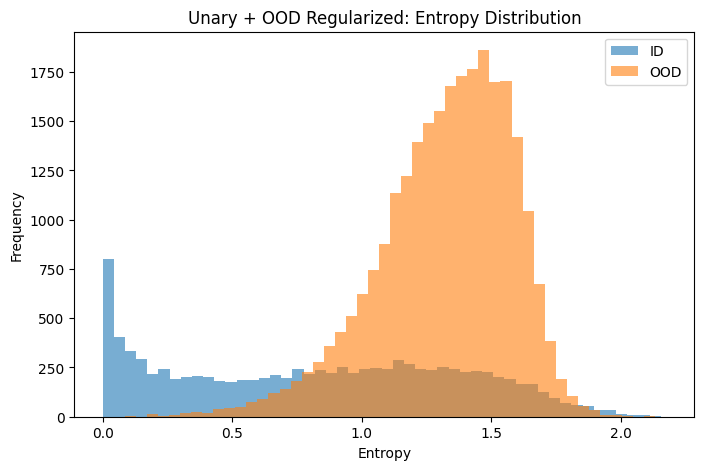

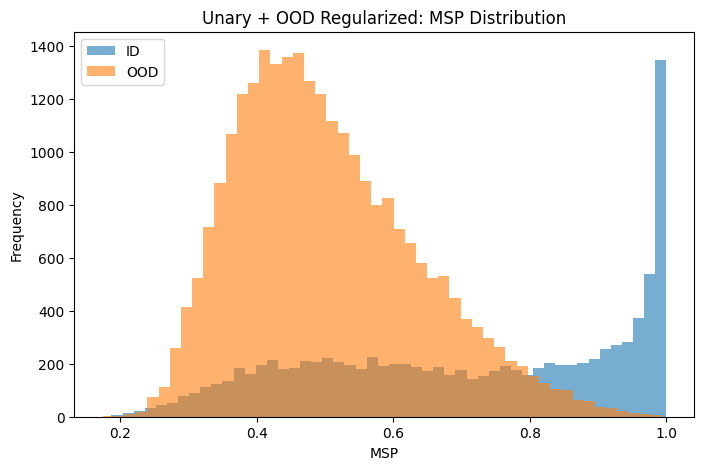

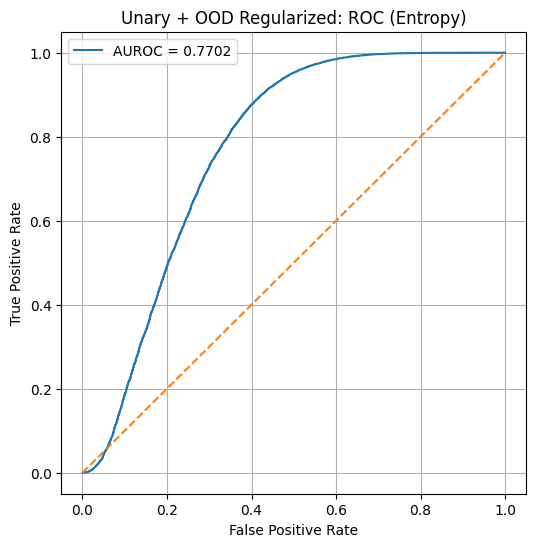

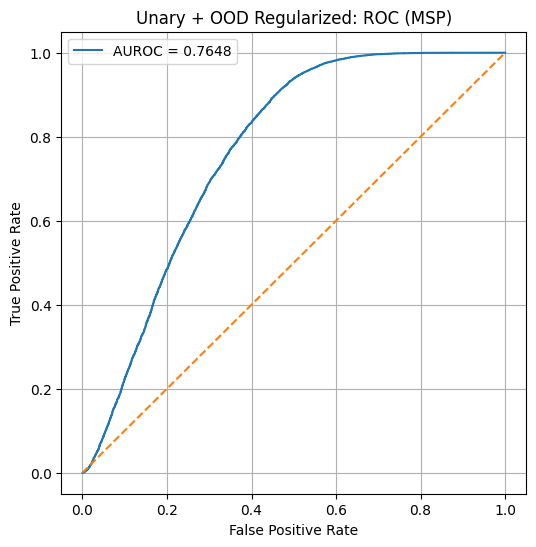

Unary + OOD Regularized OOD Metrics
----------------------------------------
Entropy AUROC: 0.7702
MSP AUROC: 0.7648


In [ ]:
unary_reg_ood_id_results = evaluate_model(
    model=model_unary_reg_ood,
    loader=test_loader,
    device=device
)

unary_reg_ood_ood_results = evaluate_model(
    model=model_unary_reg_ood,
    loader=svhn_loader,
    device=device
)
unary_reg_ood_metrics = evaluate_ood(
    id_probs=unary_reg_ood_id_results["probs"],
    ood_probs=unary_reg_ood_ood_results["probs"],
    model_name="Unary + OOD Regularized"
)

Unary + OOD Regularized reject curves: 100%|██████████| 50/50 [00:00<00:00, 9883.83it/s]


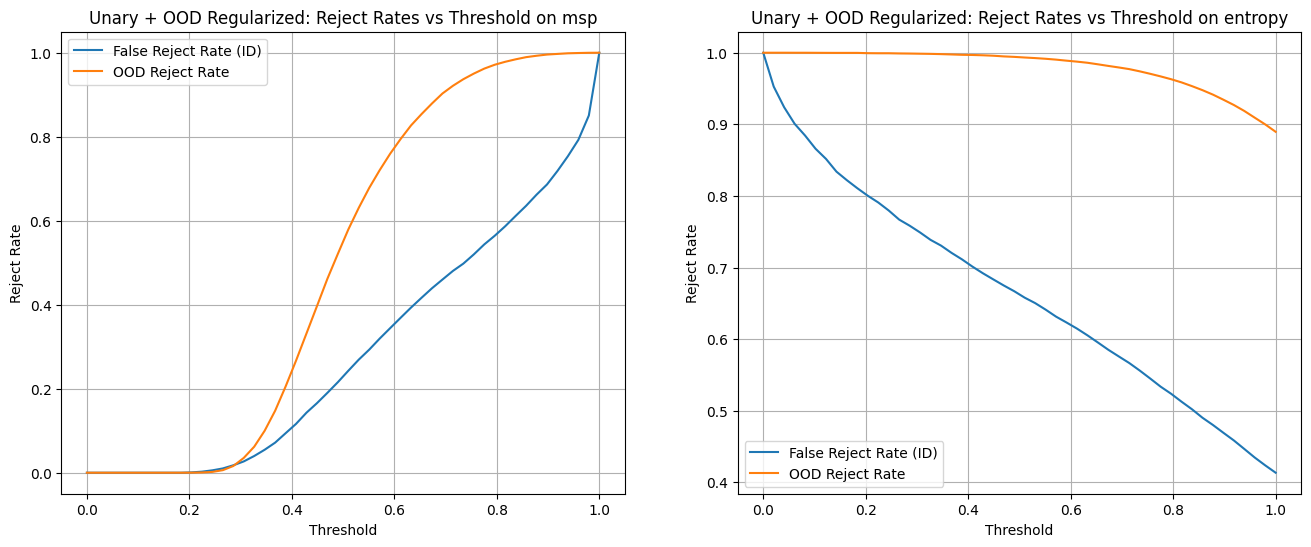

In [ ]:
plot_reject_curves(
    id_probs=unary_reg_ood_id_results["probs"],
    ood_probs=unary_reg_ood_ood_results["probs"],
    model_name="Unary + OOD Regularized"
)

## Train more epochs

In [ ]:
steps, train_steps = 4, 10

fr_list_unary_reg_ood, orr_list_unary_reg_ood = progressive_training_evaluation(
    model_unary_reg_ood,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    svhn_loader,
    device,
    steps=steps,
    train_steps=train_steps,
    ood_mode=True,
    model_mode='onehot',
    ood_ratio=0.1,
    score_mode="entropy"
)



100%|██████████| 782/782 [00:13<00:00, 60.12it/s, acc=0.687, loss=0.171]


Epoch 1/10 | loss=0.1439 | acc=0.6873


100%|██████████| 782/782 [00:13<00:00, 60.05it/s, acc=0.706, loss=0.138]


Epoch 2/10 | loss=0.1369 | acc=0.7060


100%|██████████| 782/782 [00:13<00:00, 59.83it/s, acc=0.717, loss=0.125]


...

Epoch 9/10 | loss=0.1031 | acc=0.7922


100%|██████████| 782/782 [00:13<00:00, 58.63it/s, acc=0.794, loss=0.096]


Epoch 10/10 | loss=0.1027 | acc=0.7941


Model reject curves: 100%|██████████| 50/50 [00:00<00:00, 7138.03it/s]

step: 4/4: 
	FR = 0.6518679999999999
	ORR = 0.9763375845113709


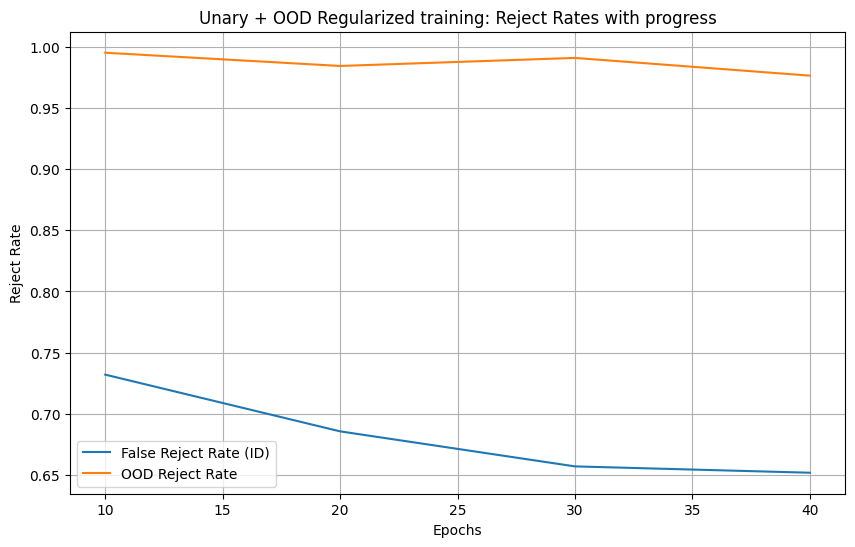

In [ ]:
epochs = train_steps, (steps+1)*train_steps, train_steps
plot_reject_rate_by_epochs(epochs, fr_list_unary_reg_ood, orr_list_unary_reg_ood, model="Unary + OOD Regularized training")

###Evaluation after additional epochs

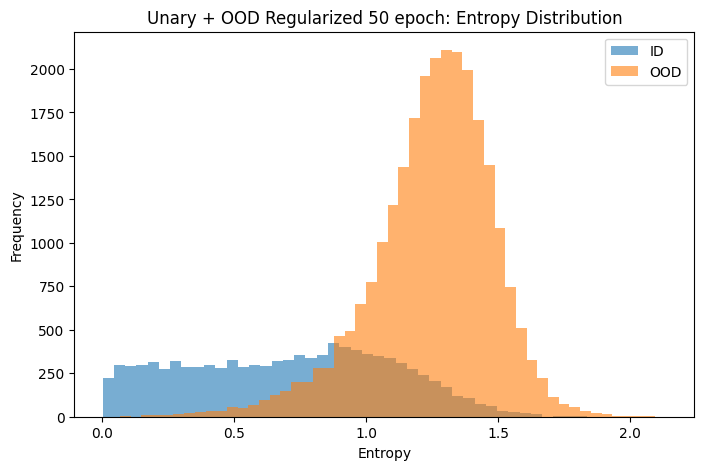

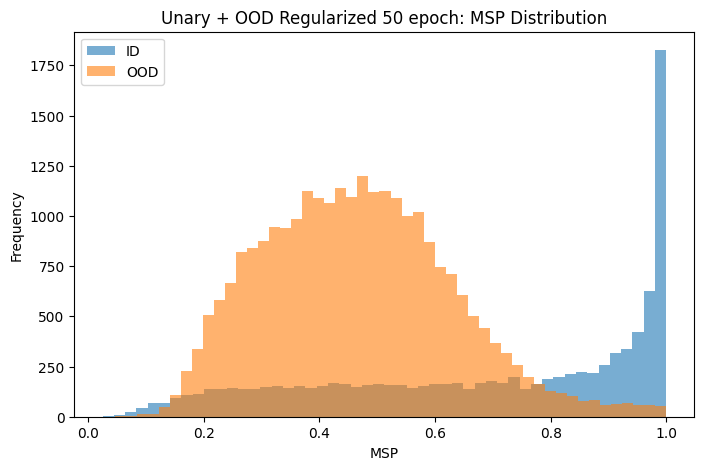

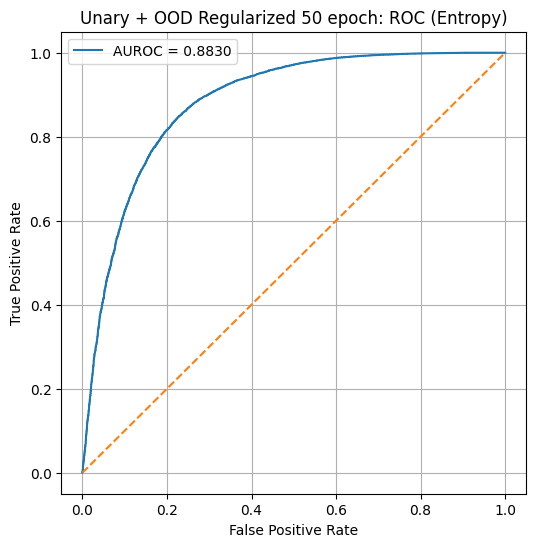

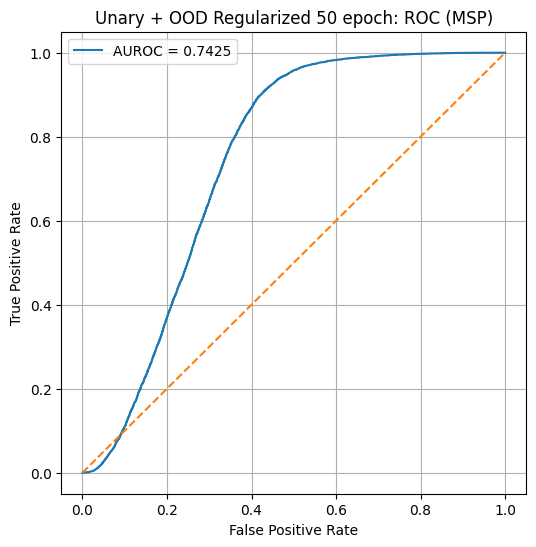

Unary + OOD Regularized 50 epoch OOD Metrics
----------------------------------------
Entropy AUROC: 0.8830
MSP AUROC: 0.7425


In [ ]:
unary_reg_ood_id_results_50e = evaluate_model(
    model=model_unary_reg_ood,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_reg_ood_ood_results_50e = evaluate_model(
    model=model_unary_reg_ood,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_reg_ood_metrics_50e = evaluate_ood(
    id_probs=unary_reg_ood_id_results_50e["probs"],
    ood_probs=unary_reg_ood_ood_results_50e["probs"],
    model_name="Unary + OOD Regularized 50 epoch"
)

Unary + OOD Regularized 50 epoch reject curves: 100%|██████████| 50/50 [00:00<00:00, 11345.77it/s]


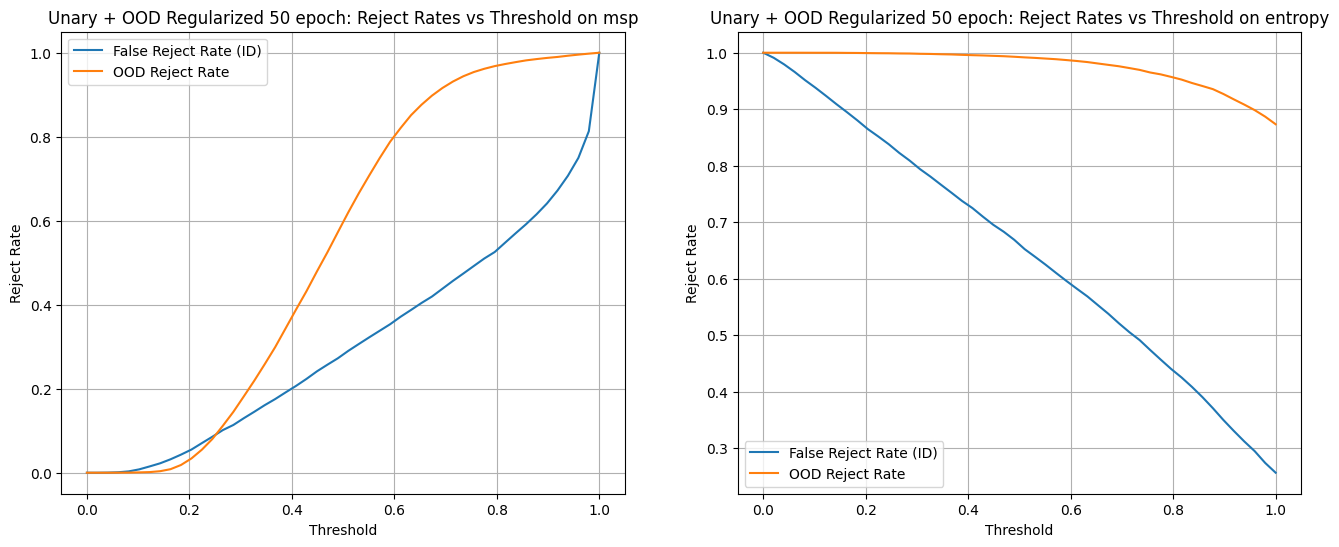

In [ ]:
plot_reject_curves(
    id_probs=unary_reg_ood_id_results_50e["probs"],
    ood_probs=unary_reg_ood_ood_results_50e["probs"],
    model_name="Unary + OOD Regularized 50 epoch"
)